# Validating the 3-parameter Buchdahl Dispersion Model
## …by asking: does it actually guide real lens-design decisions?

The main notebook (`model_glass_buchdahl.ipynb`) trained a Buchdahl model
that maps $(n_d, V_d, \Delta P_{g,F}) \to n(\lambda)$. Summary-table
numbers (max fit error, RMS, etc.) show that it *fits data* well. That
is necessary but not sufficient — we also need evidence that the model
is **physically meaningful** and **useful for decisions**. This notebook
assembles that evidence through a concrete apochromatic-doublet design
task, organized as five explicit claims:

| Claim | Statement | Evidence |
|---|---|---|
| **A** | The predicted $n(\lambda)$ is accurate enough for design use | N-BK7 sanity check over the full visible band |
| **B** | $\Delta P_{g,F}$ is a **physically meaningful** axis, not a statistical artefact | Scatter of achievable secondary spectrum vs. $\Delta P_{g,F}$ across all feasible CDGM crown candidates |
| **C** | The model's **decisions** line up with established optical-design practice | The top-ranked crowns for apo-doublet design are the FK / fluor-crown family — the same glasses used in real apochromats |
| **D** | The continuous model's **target** informs design decisions, even when it falls outside the catalog hull | Model-predicted optimum vs. best real CDGM glass, with an explicit training-hull check |
| **E** | The model is **locally smooth enough** in $(n_d, V_d)$ for first-order sensitivity studies | 2-D heatmap $S(\Delta n_d, \Delta V_d)$ around a nominal glass, plus 1-D slices |

**Physics of the test.** For each candidate crown we **redesign a
cemented doublet from scratch** — solve $(r_1, r_3)$ so the lens hits a
target EFL and has zero primary axial color. The only chromatic
aberration left is the secondary spectrum $S = |\text{BFL}(\lambda_g) - \text{BFL}(\lambda_d)|$, and $S$ is the headline figure of merit for
apochromats. Conrady's formula for a thin achromat says

$$S \approx f \cdot \frac{P_\text{crown} - P_\text{flint}}{V_\text{crown} - V_\text{flint}},$$

so $S$ is strongly controlled by the glass-pair
partial-dispersion balance. Because $\Delta P_{g,F}$ parametrizes the
deviation from the Schott normal line, it is a convenient single axis
to explore, but it should be read together with $V_d$ and $P_{g,F}$,
which jointly set the numerator and denominator of the Conrady
expression. That is why $S$ is a natural probe of whether the 3rd
Buchdahl axis carries real information.


## 0. Setup — load pretrained Buchdahl regression

The regression matrix $A \in \mathbb{R}^{20 \times 2}$ was fit once in the
main notebook and saved to `regression_buchdahl_nu34_20dim_opt.npy` (the $\alpha=1.818$ version). Here we
just load it and redefine the runtime-prediction function.


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import importlib.util

import numpy as np
import yaml
import matplotlib.pyplot as plt

import optiland.backend as be
from optiland import optic
from optiland.materials.base import BaseMaterial
from optiland.visualization import OpticViewer

np.random.seed(0)


# ============================================================
#  Design targets and feasibility specs
# ============================================================
TARGET_EFL            = 20.0   # mm, d-line EFL held fixed across all cases
TARGET_FNO            = 6.0    # F-number fixes EPD = EFL / FNO
SECSPEC_SPEC_UM       = 15.0   # max allowed secondary spectrum (see definition)
INDEX_ACCURACY_SPEC   = 5e-3   # Buchdahl prediction error budget for n(lambda)
                               # matches model's real capability (main notebook
                               # reports max err 7.6e-3, mean 3.4e-3 across 543 glasses)
MC_YIELD_TARGET       = 0.95   # acceptable min. Monte Carlo pass rate

def verdict(condition, label_pass="PASS", label_fail="FAIL"):
    return f"[{label_pass}]" if condition else f"[{label_fail}]"


In [2]:
# --- Buchdahl constants (identical to model_glass_buchdahl.ipynb) ---
LAMBDA_D = 0.5875618
LAMBDA_g = 0.4358343
LAMBDA_F = 0.4861327
LAMBDA_C = 0.6562725
ALPHA    = 1.818  # optimized alpha from main notebook (539/543 glasses < 5e-3)


def buchdahl_omega(lam, lam_d=LAMBDA_D, alpha=ALPHA):
    dl = lam - lam_d
    return dl / (1.0 + alpha * dl)


OMEGA_g = buchdahl_omega(LAMBDA_g)
OMEGA_F = buchdahl_omega(LAMBDA_F)
OMEGA_C = buchdahl_omega(LAMBDA_C)


def analytical_nu12(nd, vd, dPgF):
    dn_FC = (nd - 1.0) / vd
    PgF   = 0.6438 - 0.001682 * vd + dPgF
    dn_gF = PgF * dn_FC
    M = np.array([
        [OMEGA_F - OMEGA_C,   OMEGA_F**2 - OMEGA_C**2],
        [OMEGA_g - OMEGA_F,   OMEGA_g**2 - OMEGA_F**2],
    ])
    return np.linalg.solve(M, np.array([dn_FC, dn_gF]))


def feature_vec(nd, vd, dPgF):
    square = np.array([
        1.0, nd, vd, dPgF,
        nd**2, vd**2, dPgF**2,
        nd*vd, nd*dPgF, vd*dPgF,
    ], dtype=np.float64)
    cube = np.array([
        nd**3, vd**3, dPgF**3,
        nd**2*vd, nd**2*dPgF,
        vd**2*nd, vd**2*dPgF,
        dPgF**2*nd, dPgF**2*vd,
        nd*vd*dPgF,
    ], dtype=np.float64)
    return np.concatenate([square, cube])


A_REG = np.load("../data/regression_buchdahl_nu34_20dim_opt.npy")  # matches ALPHA=1.818
print(f"Loaded A_reg: shape = {A_REG.shape}  (alpha = {ALPHA})")


def predict_index_buchdahl(nd, vd, dPgF, lam, A_reg=A_REG, alpha=ALPHA):
    """Full n(lambda) prediction from three physical parameters."""
    nu12 = analytical_nu12(nd, vd, dPgF)
    nu34 = feature_vec(nd, vd, dPgF) @ A_reg
    omega = buchdahl_omega(np.asarray(lam, dtype=np.float64), alpha=alpha)
    nu_all = np.array([nu12[0], nu12[1], nu34[0], nu34[1]])
    result = np.full_like(omega, float(nd), dtype=np.float64)
    for k, nu_k in enumerate(nu_all, start=1):
        result = result + nu_k * omega**k
    return result


Loaded A_reg: shape = (20, 2)  (alpha = 1.818)


### Claim A — the predicted $n(\lambda)$ is accurate enough

Pick a glass we trust (N-BK7: $n_d=1.5168$, $V_d=64.17$, $\Delta
P_{g,F}\approx 0.0034$), compare the Buchdahl prediction against the
full Sellmeier curve over 400–700 nm. The budget is $|\Delta n| < 5
\times 10^{-3}$ — loose enough not to dominate typical manufacturing
tolerances, strict enough to drive apo-level design decisions.

*If Claim A fails, nothing downstream is meaningful.*


In [3]:
# N-BK7: Schott Sellmeier + d/F/C reference
nd_bk7, vd_bk7, dPgF_bk7 = 1.5168, 64.17, 0.0034
BK7 = dict(B1=1.03961212,  C1=6.00069867e-3,
           B2=0.23179234,  C2=2.00179144e-2,
           B3=1.01046945,  C3=1.03560653e2)

def sellmeier(lam, B1, C1, B2, C2, B3, C3):
    wl2 = lam**2
    return np.sqrt(1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3))

lam_scan = np.linspace(0.40, 0.70, 200)
n_true   = sellmeier(lam_scan, **BK7)
n_pred   = predict_index_buchdahl(nd_bk7, vd_bk7, dPgF_bk7, lam_scan)
err      = n_pred - n_true
err_max  = float(np.max(np.abs(err)))
err_rms  = float(np.sqrt(np.mean(err**2)))

# Spot checks at F / d / C
def n_at(lam):
    return float(predict_index_buchdahl(nd_bk7, vd_bk7, dPgF_bk7, np.array([lam]))[0])

print("N-BK7 spot checks (reference = Schott datasheet):")
print(f"  n(F=0.4861)  pred={n_at(LAMBDA_F):.6f}   ref=1.522380   err={n_at(LAMBDA_F)-1.52238:+.2e}")
print(f"  n(d=0.5876)  pred={n_at(LAMBDA_D):.6f}   ref=1.516800   err={n_at(LAMBDA_D)-1.51680:+.2e}")
print(f"  n(C=0.6563)  pred={n_at(LAMBDA_C):.6f}   ref=1.514320   err={n_at(LAMBDA_C)-1.51432:+.2e}")
print()
print("Full-band fit quality (400-700 nm, N=200):")
print(f"  Max |error|: {err_max:.2e}    (budget {INDEX_ACCURACY_SPEC:.0e})   {verdict(err_max < INDEX_ACCURACY_SPEC)}")
print(f"  RMS error:   {err_rms:.2e}")


N-BK7 spot checks (reference = Schott datasheet):
  n(F=0.4861)  pred=1.522492   ref=1.522380   err=+1.12e-04
  n(d=0.5876)  pred=1.516800   ref=1.516800   err=+0.00e+00
  n(C=0.6563)  pred=1.514343   ref=1.514320   err=+2.28e-05

Full-band fit quality (400-700 nm, N=200):
  Max |error|: 3.63e-04    (budget 5e-03)   [PASS]
  RMS error:   1.52e-04


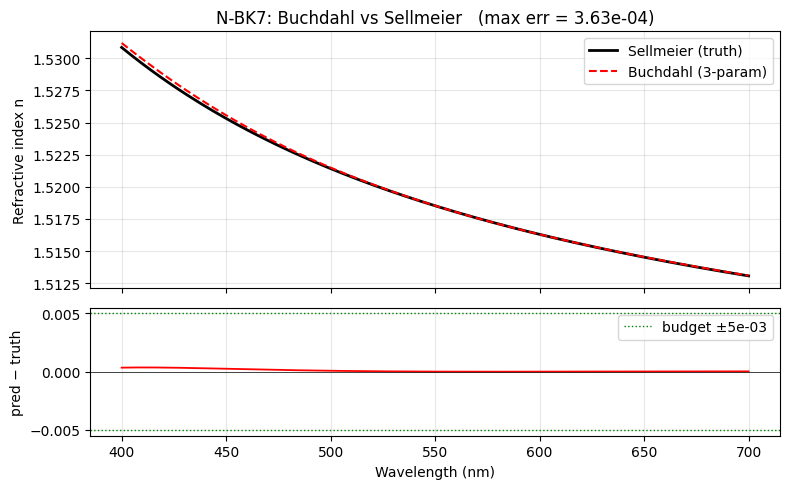

In [4]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 5), sharex=True,
                               gridspec_kw=dict(height_ratios=[2, 1]))
a1.plot(lam_scan*1e3, n_true, 'k-',  lw=2,   label='Sellmeier (truth)')
a1.plot(lam_scan*1e3, n_pred, 'r--', lw=1.5, label='Buchdahl (3-param)')
a1.set_ylabel('Refractive index n')
a1.set_title(f'N-BK7: Buchdahl vs Sellmeier   (max err = {err_max:.2e})')
a1.legend()
a1.grid(alpha=0.3)

a2.plot(lam_scan*1e3, err, 'r-', lw=1.3)
a2.axhline( INDEX_ACCURACY_SPEC, color='g', ls=':', lw=1, label=f'budget ±{INDEX_ACCURACY_SPEC:.0e}')
a2.axhline(-INDEX_ACCURACY_SPEC, color='g', ls=':', lw=1)
a2.axhline(0, color='k', lw=0.5)
a2.set_xlabel('Wavelength (nm)')
a2.set_ylabel('pred − truth')
a2.legend()
a2.grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 1. Custom Optiland material class

Optiland materials all subclass `BaseMaterial` and implement `_calculate_n`
/ `_calculate_k`. We wrap the Buchdahl prediction in a new class so a
surface can consume arbitrary $(n_d, V_d, \Delta P_{g,F})$ triples.


In [5]:
class BuchdahlModelGlass(BaseMaterial):
    """Model glass driven by three physical parameters (nd, Vd, dPgF)."""

    def __init__(self, nd: float, vd: float, dPgF: float, label: str = "model"):
        super().__init__()
        self.nd = float(nd)
        self.vd = float(vd)
        self.dPgF = float(dPgF)
        self.label = label

    def _calculate_n(self, wavelength, **kwargs):
        lam_np = np.atleast_1d(be.to_numpy(wavelength)).astype(np.float64)
        n = predict_index_buchdahl(self.nd, self.vd, self.dPgF, lam_np)
        n = np.asarray(n, dtype=np.float64).reshape(np.shape(wavelength) or (1,))
        return be.array(n)

    def _calculate_k(self, wavelength, **kwargs):
        shape = np.shape(wavelength) or (1,)
        return be.array(np.zeros(shape, dtype=np.float64))

    def to_dict(self):
        d = super().to_dict()
        d.update({"nd": self.nd, "vd": self.vd, "dPgF": self.dPgF,
                  "label": self.label})
        return d

    def __repr__(self):
        return (f"BuchdahlModelGlass({self.label!r}, nd={self.nd:.4f}, "
                f"Vd={self.vd:.2f}, dPgF={self.dPgF:+.4f})")


# Quick smoke test
mg = BuchdahlModelGlass(1.697, 55.4, -0.009, label="N-LAK14-like")
print(mg)
print(f"  n(F) = {be.to_numpy(mg.n(LAMBDA_F)).item():.6f}")
print(f"  n(d) = {be.to_numpy(mg.n(LAMBDA_D)).item():.6f}")
print(f"  n(C) = {be.to_numpy(mg.n(LAMBDA_C)).item():.6f}")


BuchdahlModelGlass('N-LAK14-like', nd=1.6970, Vd=55.40, dPgF=-0.0090)
  n(F) = 1.705919
  n(d) = 1.697000
  n(C) = 1.693168


## 2. Catalog loader — parameters from Sellmeier data

Every glass in this notebook is described by the same three-parameter
record: $(n_d, V_d, \Delta P_{g,F})$, optionally accompanied by the full
partial dispersion $P_{g,F}$ and the raw Sellmeier coefficients. We
recompute these from the Optiland YAML catalogs using the **exact same
pipeline as `model_glass_buchdahl.ipynb`** — no hand-typed nominal
values. This keeps definitions consistent across notebooks and avoids
silent sign errors on $\Delta P_{g,F}$.


In [6]:
# ------------------------------------------------------------------
#  Catalog access -- reused by baseline loader, CDGM sweep, training
#  hull check and the Sellmeier cross-check. Defined once, here.
# ------------------------------------------------------------------
if "OPTILAND_DB_ROOT" in os.environ:
    DB_ROOT = Path(os.environ["OPTILAND_DB_ROOT"])
else:
    _spec = importlib.util.find_spec("optiland")
    if _spec is None or _spec.origin is None:
        raise RuntimeError(
            "optiland not installed. Either `pip install optiland` or set "
            "OPTILAND_DB_ROOT to the database directory."
        )
    DB_ROOT = Path(_spec.origin).parent / "database"
GLASS_ROOT = DB_ROOT / "data-nk" / "glass"


def _sellmeier_n(lam, B1, C1, B2, C2, B3, C3):
    wl2 = lam ** 2
    return np.sqrt(1 + B1*wl2/(wl2-C1) + B2*wl2/(wl2-C2) + B3*wl2/(wl2-C3))


def extract_record(yml_path: Path):
    """Load one Optiland YAML glass file and recompute (nd, Vd, PgF,
    dPgF) from its Sellmeier formula. Returns None if the file uses a
    non-Sellmeier formula or is malformed. Raw coefficients are kept so
    downstream cells can do Sellmeier-truth cross-checks without
    re-parsing."""
    with yml_path.open("r", encoding="utf-8") as f:
        doc = yaml.safe_load(f)
    data_blocks = doc.get("DATA", [])
    if not data_blocks:
        return None
    formula = data_blocks[0]
    if formula.get("type") != "formula 2":
        return None
    coeffs = formula.get("coefficients", "").split()
    if len(coeffs) != 7:
        return None
    wr = formula.get("wavelength_range", "").split()
    if len(wr) != 2:
        return None
    B1, C1 = float(coeffs[1]), float(coeffs[2])
    B2, C2 = float(coeffs[3]), float(coeffs[4])
    B3, C3 = float(coeffs[5]), float(coeffs[6])
    lam_lo, lam_hi = float(wr[0]), float(wr[1])
    # Must span at least g..C so the partial dispersion is well defined.
    if lam_lo > LAMBDA_g or lam_hi < LAMBDA_C:
        return None
    sm = (B1, C1, B2, C2, B3, C3)
    nd = _sellmeier_n(LAMBDA_D, *sm)
    nF = _sellmeier_n(LAMBDA_F, *sm)
    nC = _sellmeier_n(LAMBDA_C, *sm)
    ng = _sellmeier_n(LAMBDA_g, *sm)
    dn_FC = nF - nC
    if dn_FC < 1e-12:
        return None
    vd   = (nd - 1.0) / dn_FC
    PgF  = (ng - nF) / dn_FC
    dPgF = PgF - (0.6438 - 0.001682 * vd)
    return dict(
        name=yml_path.stem, catalog=yml_path.parent.name,
        nd=float(nd), vd=float(vd),
        PgF=float(PgF), dPgF=float(dPgF),
        sellmeier=sm,
        wavelength_range=(lam_lo, lam_hi),
    )


def get_glass_by_name(catalog: str, name: str) -> dict:
    yml = GLASS_ROOT / catalog / f"{name}.yml"
    rec = extract_record(yml)
    if rec is None:
        raise RuntimeError(f"Could not load {catalog}/{name} (path: {yml})")
    return rec


def as_model_glass(rec: dict, label: str) -> "BuchdahlModelGlass":
    """Wrap a (nd, Vd, dPgF) record as a Buchdahl-driven material."""
    return BuchdahlModelGlass(rec["nd"], rec["vd"], rec["dPgF"], label=label)


# Baseline pair for the test bench, straight from the Schott catalog.
NLAK14 = get_glass_by_name("schott", "N-LAK14")
NSF2   = get_glass_by_name("schott", "N-SF2")

print("Baseline pair recomputed from Schott Sellmeier data:")
print(f"  {'':18}{'nd':>10}{'Vd':>10}{'PgF':>10}{'dPgF':>12}")
for name, g in [("N-LAK14 (crown)", NLAK14), ("N-SF2   (flint)", NSF2)]:
    print(f"  {name:18}{g['nd']:>10.4f}{g['vd']:>10.2f}"
          f"{g['PgF']:>10.4f}{g['dPgF']:>+12.4f}")


Baseline pair recomputed from Schott Sellmeier data:
                            nd        Vd       PgF        dPgF
  N-LAK14 (crown)       1.6968     55.41    0.5427     -0.0079
  N-SF2   (flint)       1.6477     33.82    0.5950     +0.0081


## 3. Test bench — a cemented doublet, designed per glass pair

To exercise the model we need a concrete optical system. We use a
cemented doublet at F/6, **EFL = 20 mm**, and **design the achromat per
glass pair**: solve $(r_1, r_3)$ so that

$$\text{EFL}(d) = 20\,\text{mm}, \qquad \text{BFL}(F) - \text{BFL}(C) = 0$$

$r_2$ (cemented interface) is held fixed as a bending/shape factor.
Every case later — baseline, model optimum, CDGM candidates, Monte Carlo
draws — goes through the same design procedure, so they are all true
primary achromats at the same EFL and EPD, and the only thing that
varies is the crown glass.

The figure of merit is the **secondary spectrum**

$$S = \big|\text{BFL}(\lambda_g) - \text{BFL}(\lambda_d)\big|$$

The Conrady $f/2200 \approx 9\,\mu m$ rule is an order-of-magnitude
reference for an idealized thin achromat; it is **not** a guarantee for
this fixed-shape, fixed-interface test bench. The measured baseline is
therefore used only as an internal reference for this replacement
experiment. A starter pair is N-LAK14 + N-SF2 — nothing special about
this choice, just a well-known reference point.


In [7]:
# NLAK14 and NSF2 were loaded from Schott Sellmeier data in the
# previous cell (dict with nd, vd, PgF, dPgF, sellmeier, ...).


def build_doublet(crown_material, flint_material,
                  r1=12.38401, r2=-7.94140, r3=-48.44396,
                  t1=0.4340, t2=0.3210, fno=6.0):
    """Cemented doublet. Crown has surfaces (1,2); flint has (2,3).

    Image distance (t3) is solved per lens so the image plane sits at the
    paraxial d-line focus. Without this, the fixed t3 inherited from the
    original Laikin prescription would leave most swaps defocused at the
    image plane, which confuses both the numbers and the 2-D rendering.
    """
    lens = optic.Optic()
    s = lens.surfaces
    s.add(index=0, radius=be.inf, thickness=be.inf)
    s.add(index=1, radius=r1, thickness=t1, is_stop=True, material=crown_material)
    s.add(index=2, radius=r2, thickness=t2, material=flint_material)
    s.add(index=3, radius=r3, thickness=0.0)
    s.add(index=4)
    lens.set_aperture(aperture_type="imageFNO", value=fno)
    lens.fields.set_type(field_type="angle")
    lens.fields.add(y=0)
    lens.wavelengths.add(value=LAMBDA_F)
    lens.wavelengths.add(value=LAMBDA_D, is_primary=True)
    lens.wavelengths.add(value=LAMBDA_C)
    lens.updater.image_solve()
    return lens


def bfl_at_wavelength(lens, wavelength):
    """Paraxial BFL at given wavelength. Collimated axial bundle."""
    EPD = float(lens.paraxial.EPD())
    y = EPD / 2.0
    ya, ua = lens.paraxial.trace_generic(y=y, u=0.0, z=0.0,
                                         wavelength=wavelength, skip=1)
    y_np = np.asarray(be.to_numpy(ya)).ravel()
    u_np = np.asarray(be.to_numpy(ua)).ravel()
    # Last surface is image plane (no refraction). Use the penultimate
    # surface's ray slope to find where it crosses the axis.
    return float(-y_np[-2] / u_np[-2])


def axial_color(lens):
    bfl_F = bfl_at_wavelength(lens, LAMBDA_F)
    bfl_d = bfl_at_wavelength(lens, LAMBDA_D)
    bfl_C = bfl_at_wavelength(lens, LAMBDA_C)
    return bfl_F - bfl_C, (bfl_F, bfl_d, bfl_C)


def design_achromat(crown_material, flint_material,
                    target_efl=TARGET_EFL, r2=-7.94140,
                    t1=0.434, t2=0.321, fno=TARGET_FNO,
                    r1_init=12.38401, r3_init=-48.44396):
    """Solve (r1, r3) so the doublet is a primary achromat at target EFL.

    Two equations, two unknowns:
      - EFL(d)               = target_efl
      - BFL(F) - BFL(C)      = 0           (primary achromatic condition)

    r2 (cemented interface) stays fixed. After design, the only residual
    chromatic error is the secondary spectrum — exactly what partial
    dispersion (dPgF) controls.
    """
    from scipy.optimize import fsolve

    def equations(radii):
        r1, r3 = radii
        try:
            lens = build_doublet(crown_material, flint_material,
                                 r1=float(r1), r2=r2, r3=float(r3),
                                 t1=t1, t2=t2, fno=fno)
            efl_err = float(lens.paraxial.f2()) - target_efl
            ax_err, _ = axial_color(lens)
        except Exception:
            return [1e6, 1e6]
        return [efl_err, ax_err]

    sol, info, ier, msg = fsolve(equations, x0=[r1_init, r3_init],
                                 full_output=True, xtol=1e-10)
    if ier != 1:
        raise RuntimeError(f"achromat design failed: {msg}")
    r1, r3 = float(sol[0]), float(sol[1])
    lens = build_doublet(crown_material, flint_material,
                         r1=r1, r2=r2, r3=r3, t1=t1, t2=t2, fno=fno)
    return lens, (r1, r3)


# -----------------------------------------------------------------
#  Fast numpy paraxial path — bypasses Optiland's per-call overhead
#  inside the fsolve loop. Same math, just without building an Optic
#  every iteration. Used for the CDGM sweep, the 441-cell
#  heatmap, and the 200-sample Monte Carlo.
#
#  Optiland is still used for the baseline/optimum/winner final
#  lenses (visualization, verification, chromatic focal shift plot).
# -----------------------------------------------------------------
def paraxial_trace(r1, r2, r3, t1, t2, n_crown, n_flint):
    """Paraxial trace of a cemented doublet from a collimated axial bundle.

    Inputs are scalars. Indices may be scalar or array (broadcastable).
    Returns (EFL, BFL).
    """
    y, u = 1.0, 0.0
    u = (u - (n_crown - 1.0) * y / r1) / n_crown                   # surf 1
    y = y + u * t1
    u = (n_crown * u - (n_flint - n_crown) * y / r2) / n_flint     # surf 2
    y = y + u * t2
    u = n_flint * u - (1.0 - n_flint) * y / r3                     # surf 3
    return -1.0 / u, -y / u


def design_achromat_fast(nd_c, vd_c, dPgF_c, nd_f, vd_f, dPgF_f,
                         target_efl=TARGET_EFL, r2=-7.94140,
                         t1=0.434, t2=0.321,
                         r1_init=12.38401, r3_init=-48.44396):
    """Solve (r1, r3) via pure-numpy paraxial trace. ~30x faster than
    the Optiland-based `design_achromat`. Returns (r1, r3)."""
    from scipy.optimize import fsolve

    lams = np.array([LAMBDA_F, LAMBDA_D, LAMBDA_C])
    n_c = predict_index_buchdahl(nd_c, vd_c, dPgF_c, lams)
    n_f = predict_index_buchdahl(nd_f, vd_f, dPgF_f, lams)

    def residuals(radii):
        r1, r3 = radii
        efl_d, _ = paraxial_trace(r1, r2, r3, t1, t2, n_c[1], n_f[1])
        _, bfl_F = paraxial_trace(r1, r2, r3, t1, t2, n_c[0], n_f[0])
        _, bfl_C = paraxial_trace(r1, r2, r3, t1, t2, n_c[2], n_f[2])
        return [efl_d - target_efl, bfl_F - bfl_C]

    sol, info, ier, msg = fsolve(residuals, x0=[r1_init, r3_init],
                                 full_output=True, xtol=1e-10)
    if ier != 1:
        raise RuntimeError(f"fast achromat design failed: {msg}")
    return float(sol[0]), float(sol[1])


def secondary_spectrum_fast(r1, r3, nd_c, vd_c, dPgF_c,
                            nd_f, vd_f, dPgF_f,
                            r2=-7.94140, t1=0.434, t2=0.321):
    """|BFL(g) - BFL(d)| in mm, using the fast paraxial path."""
    lams = np.array([LAMBDA_g, LAMBDA_D])
    n_c = predict_index_buchdahl(nd_c, vd_c, dPgF_c, lams)
    n_f = predict_index_buchdahl(nd_f, vd_f, dPgF_f, lams)
    _, bfl_g = paraxial_trace(r1, r2, r3, t1, t2, n_c[0], n_f[0])
    _, bfl_d = paraxial_trace(r1, r2, r3, t1, t2, n_c[1], n_f[1])
    return abs(bfl_g - bfl_d)


# Wavelength sweep used by the chromatic focal shift plot downstream.
LAM_SCAN = np.linspace(0.400, 0.700, 41)


def secondary_spectrum(lens):
    """Textbook secondary spectrum: |BFL(g) - BFL(d)|, in mm.

    This is the standard Conrady / optical-design definition: after
    primary achromatization forces BFL(F) = BFL(C), the g-line focal
    offset is what remains. A two-glass achromat with matched partial
    dispersions gives ~f / 2200, i.e. ~9 um at f = 20 mm.
    """
    return abs(bfl_at_wavelength(lens, LAMBDA_g)
               - bfl_at_wavelength(lens, LAMBDA_D))


# Design the baseline achromat for N-LAK14 + N-SF2 at target EFL
crown0 = as_model_glass(NLAK14, label="N-LAK14 (model)")
flint0 = as_model_glass(NSF2,   label="N-SF2 (model)")
baseline, (r1_base, r3_base) = design_achromat(crown0, flint0,
                                               target_efl=TARGET_EFL)

# Measurements on the designed achromat
ax0, (bfl_F0, bfl_d0, bfl_C0) = axial_color(baseline)
ax0_um  = ax0 * 1e3
sec0    = secondary_spectrum(baseline)
sec0_um = sec0 * 1e3
efl0    = float(baseline.paraxial.f2())
epd0    = float(baseline.paraxial.EPD())

print("Baseline achromat: N-LAK14 + N-SF2  (designed, not inherited)")
print(f"  Design targets:  EFL={TARGET_EFL:.2f} mm,  AxColor=0,  r2 fixed")
print(f"  Solved:          r1 = {r1_base:+.4f} mm,  r3 = {r3_base:+.4f} mm")
print()
print(f"  First-order:     EFL(d) = {efl0:.4f} mm  (target {TARGET_EFL:.2f})")
print(f"                   EPD    = {epd0:.4f} mm  (= EFL / FNO)")
print(f"  Primary color:   AxColor = BFL(F)-BFL(C) = {ax0_um:+.3f} um   (should be ~0)")
print(f"  Secondary color: max|BFL(lam)-BFL(d)|    = {sec0_um:7.2f} um   <- headline metric")
print()
print(f"Baseline benchmark  S_0 = {sec0_um:.2f} um  "
      "(internal reference for this fixed-shape test bench;")
print("                   Conrady f/2200 ~ 9 um is an idealized thin-achromat")
print("                   estimate and need not match this configuration)")

# --- Verification: fast numpy path matches Optiland ---
r1_fast, r3_fast = design_achromat_fast(
    NLAK14['nd'], NLAK14['vd'], NLAK14['dPgF'],
    NSF2['nd'],   NSF2['vd'],   NSF2['dPgF'],
)
sec_fast_um = secondary_spectrum_fast(
    r1_fast, r3_fast,
    NLAK14['nd'], NLAK14['vd'], NLAK14['dPgF'],
    NSF2['nd'],   NSF2['vd'],   NSF2['dPgF'],
) * 1e3

print("\nFast numpy path vs. Optiland (used in the 18,000+ inner-loop calls):")
print(f"  r1:  optiland={r1_base:+.6f}  fast={r1_fast:+.6f}  "
      f"diff={r1_fast - r1_base:+.2e}")
print(f"  r3:  optiland={r3_base:+.6f}  fast={r3_fast:+.6f}  "
      f"diff={r3_fast - r3_base:+.2e}")
print(f"  S :  optiland={sec0_um:7.4f}  fast={sec_fast_um:7.4f}  "
      f"diff={sec_fast_um - sec0_um:+.2e}")
print("  (Tolerance: diffs should be < 1e-4 mm or 1e-3 um)")


Baseline achromat: N-LAK14 + N-SF2  (designed, not inherited)
  Design targets:  EFL=20.00 mm,  AxColor=0,  r2 fixed
  Solved:          r1 = +16.7479 mm,  r3 = -278.8414 mm

  First-order:     EFL(d) = 20.0000 mm  (target 20.00)
                   EPD    = 3.3333 mm  (= EFL / FNO)
  Primary color:   AxColor = BFL(F)-BFL(C) = -0.000 um   (should be ~0)
  Secondary color: max|BFL(lam)-BFL(d)|    =   69.91 um   <- headline metric

Baseline benchmark  S_0 = 69.91 um  (internal reference for this fixed-shape test bench;
                   Conrady f/2200 ~ 9 um is an idealized thin-achromat
                   estimate and need not match this configuration)

Fast numpy path vs. Optiland (used in the 18,000+ inner-loop calls):
  r1:  optiland=+16.747885  fast=+16.747885  diff=-2.84e-13
  r3:  optiland=-278.841426  fast=-278.841426  diff=-8.84e-11
  S :  optiland=69.9140  fast=69.9140  diff=+7.11e-12
  (Tolerance: diffs should be < 1e-4 mm or 1e-3 um)


### 2D layout of the baseline doublet

Optiland's `OpticViewer` draws the surface outlines and traces the marginal
and chief rays. On-axis rays only — this is a telescope-like axial
configuration.


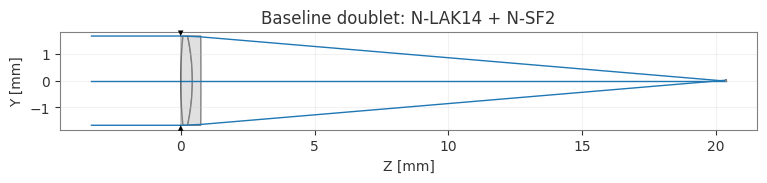

In [8]:
viewer = OpticViewer(baseline)
viewer.view(figsize=(9, 3), title="Baseline doublet: N-LAK14 + N-SF2")
plt.show()


## 4. What does the model predict the best crown should be?

This step asks the Buchdahl model directly: *given freedom to vary
$(n_d, V_d, \Delta P_{g,F})$ continuously within the training domain,
what crown glass minimizes $S$?* The answer will serve two purposes —
first, sanity-check that the model agrees with known physics (the
optimum should sit at anomalous dispersion), and second, give us a
reference point for **Claim D** (the gap between model-ideal and real
catalog).

The search is bounded to rectangular parameter ranges for numerical
protection, but the **true** training domain is the 3-D convex hull of
the real glasses used to fit the regression. An optimum that sits inside
the hull is a plausible *physical* target; one outside is extrapolation
— model-space guidance, not a claim that a missing glass exists.


In [9]:
# ---------------------------------------------------------------
#  Training-hull check: we apply the same wavelength filter as
#  `model_glass_buchdahl.ipynb` (Sellmeier range covering 0.365-2.3 um)
#  so the resulting hull approximates the actual regression training set
#  rather than a looser catalog proxy.
# ---------------------------------------------------------------
from scipy.spatial import ConvexHull

TRAIN_CATALOGS = ["schott", "cdgm", "hoya", "ohara", "sumita"]
TRAIN_LAM_LO   = 0.36501   # um -- Sellmeier range lower edge (main notebook)
TRAIN_LAM_HI   = 2.30      # um -- Sellmeier range upper edge (main notebook)


def passes_training_filter(rec):
    lo, hi = rec["wavelength_range"]
    return lo <= TRAIN_LAM_LO and hi >= TRAIN_LAM_HI


train_glasses = []
train_skipped_range = 0
for cat in TRAIN_CATALOGS:
    cat_root = GLASS_ROOT / cat
    if not cat_root.exists():
        continue
    for yml in cat_root.rglob("*.yml"):
        rec = extract_record(yml)
        if rec is None:
            continue
        if not passes_training_filter(rec):
            train_skipped_range += 1
            continue
        train_glasses.append(rec)

train_pts = np.column_stack([
    np.array([g["nd"]   for g in train_glasses]),
    np.array([g["vd"]   for g in train_glasses]),
    np.array([g["dPgF"] for g in train_glasses]),
])
train_hull = ConvexHull(train_pts)


def inside_training_hull(nd, vd, dPgF, tol=1e-10):
    p = np.array([nd, vd, dPgF])
    return bool(np.max(train_hull.equations[:, :-1] @ p
                       + train_hull.equations[:, -1]) <= tol)


print(f"Training hull built from {len(train_glasses)} catalog glasses")
print(f"  catalogs:        {', '.join(TRAIN_CATALOGS)}")
print(f"  wavelength cut:  Sellmeier must cover [{TRAIN_LAM_LO:.3f}, "
      f"{TRAIN_LAM_HI:.2f}] um")
print(f"  skipped for range:      {train_skipped_range}")
print(f"  nd   range: [{train_pts[:, 0].min():.3f}, {train_pts[:, 0].max():.3f}]")
print(f"  Vd   range: [{train_pts[:, 1].min():.2f}, {train_pts[:, 1].max():.2f}]")
print(f"  dPgF range: [{train_pts[:, 2].min():+.4f}, {train_pts[:, 2].max():+.4f}]")
print(f"  hull facets: {len(train_hull.simplices)}")
print()
print("NOTE: this is an approximate catalog-derived training hull. It applies")
print("      the same wavelength filter as `model_glass_buchdahl.ipynb` but may")
print("      not reproduce every sanity cut used during regression training, so")
print("      it should be treated as an approximation of the training domain,")
print("      not an exact reconstruction.")


Training hull built from 539 catalog glasses
  catalogs:        schott, cdgm, hoya, ohara, sumita
  wavelength cut:  Sellmeier must cover [0.365, 2.30] um
  skipped for range:      103
  nd   range: [1.434, 2.103]
  Vd   range: [16.79, 95.23]
  dPgF range: [-0.0120, +0.0564]
  hull facets: 92

NOTE: this is an approximate catalog-derived training hull. It applies
      the same wavelength filter as `model_glass_buchdahl.ipynb` but may
      not reproduce every sanity cut used during regression training, so
      it should be treated as an approximation of the training domain,
      not an exact reconstruction.


In [10]:
from scipy.optimize import minimize

# Rectangular bounds as a first-pass numerical guard. The real
# training domain is the convex hull built in the previous cell;
# membership is checked after the optimum is found.
GLASS_BOUNDS = [
    (1.44, 2.00),   # nd:   lowest = fluor-crowns (FK), highest = dense flints
    (20.0, 95.0),   # Vd
    (-0.015, 0.055),# dPgF: anomalous ED/FPL glasses at the positive end
]


def objective(x):
    nd, vd, dPgF = x
    try:
        r1, r3 = design_achromat_fast(nd, vd, dPgF,
                                       NSF2['nd'], NSF2['vd'], NSF2['dPgF'])
    except Exception:
        return 1e6
    S = secondary_spectrum_fast(r1, r3, nd, vd, dPgF,
                                NSF2['nd'], NSF2['vd'], NSF2['dPgF'])
    return S ** 2


x0 = np.array([NLAK14["nd"], NLAK14["vd"], NLAK14["dPgF"]])
res = minimize(
    objective, x0, method="Nelder-Mead",
    bounds=GLASS_BOUNDS,
    options=dict(xatol=1e-5, fatol=1e-16, maxiter=600),
)
nd_opt, vd_opt, dPgF_opt = res.x

# Flag extrapolation-adjacent results (at the boundary = tight fit)
at_boundary = []
for name, val, (lo, hi) in zip(["nd","Vd","dPgF"], res.x, GLASS_BOUNDS):
    if abs(val - lo) < 1e-3 * max(1, abs(lo)) or abs(val - hi) < 1e-3 * max(1, abs(hi)):
        at_boundary.append(name)

# Final build with Optiland (for visualization / verification only)
r1_opt, r3_opt = design_achromat_fast(nd_opt, vd_opt, dPgF_opt,
                                       NSF2['nd'], NSF2['vd'], NSF2['dPgF'])
crown_opt = BuchdahlModelGlass(nd_opt, vd_opt, dPgF_opt, label="ideal model")
flint_opt = as_model_glass(NSF2, label="N-SF2 (model)")
lens_opt = build_doublet(crown_opt, flint_opt, r1=r1_opt, r3=r3_opt)
ax_opt, _ = axial_color(lens_opt)
sec_opt = secondary_spectrum(lens_opt)

print(f"Optimizer converged: nit={res.nit}, final sec-spec^2 = {res.fun:.3e}")
print()
print(f"Continuous-model crown target (within rectangular bounds, fixed EFL={TARGET_EFL:.2f};")
print("hull membership checked below — rectangular bounds are only a numerical guard):")
print(f"  nd   = {nd_opt:.4f}   bounds {GLASS_BOUNDS[0]}   (N-LAK14: {NLAK14['nd']:.4f})")
print(f"  Vd   = {vd_opt:.2f}   bounds {GLASS_BOUNDS[1]}    (N-LAK14: {NLAK14['vd']:.2f})")
print(f"  dPgF = {dPgF_opt:+.4f}  bounds {GLASS_BOUNDS[2]}  (N-LAK14: {NLAK14['dPgF']:+.4f})"
      "  <- anomalous partial dispersion")
if at_boundary:
    print(f"\n  NOTE: optimum is at the boundary on: {', '.join(at_boundary)}")
    print("        => the true optimum likely lies outside the training domain")
    print("        (i.e. no real glass satisfies it; apo design needs >2 elements)")

# Training-domain hull check: is this point a physical glass target,
# or pure extrapolation in model space?
optimum_inside_hull = inside_training_hull(nd_opt, vd_opt, dPgF_opt)
print()
print(f"Inside 3-D training convex hull: {optimum_inside_hull}")
if not optimum_inside_hull:
    print("  => the continuous optimum lies OUTSIDE the catalog's 3-D footprint.")
    print("     Interpret it as virtual design guidance in model space, NOT as a")
    print("     proof that a manufacturable real glass with these parameters exists.")
else:
    print("  => the optimum is inside the training hull, i.e. the model is being")
    print("     evaluated where it was fit. A close real glass is plausible.")

print()
print("Redesigned achromat:")
print(f"  r1 = {r1_opt:+.4f} mm,  r3 = {r3_opt:+.4f} mm")
print(f"  EFL = {float(lens_opt.paraxial.f2()):.4f} mm   "
      f"(target {TARGET_EFL:.2f})")
print(f"  AxColor          = {ax_opt*1e3:+.3f} um   (should be ~0)")
print(f"  Secondary spec   = {sec_opt*1e3:7.2f} um   "
      f"(baseline was {sec0_um:.2f} um)")


Optimizer converged: nit=74, final sec-spec^2 = 3.163e-17

Continuous-model crown target (within rectangular bounds, fixed EFL=20.00;
hull membership checked below — rectangular bounds are only a numerical guard):
  nd   = 1.6517   bounds (1.44, 2.0)   (N-LAK14: 1.6968)
  Vd   = 82.31   bounds (20.0, 95.0)    (N-LAK14: 55.41)
  dPgF = -0.0083  bounds (-0.015, 0.055)  (N-LAK14: -0.0079)  <- anomalous partial dispersion

Inside 3-D training convex hull: False
  => the continuous optimum lies OUTSIDE the catalog's 3-D footprint.
     Interpret it as virtual design guidance in model space, NOT as a
     proof that a manufacturable real glass with these parameters exists.

Redesigned achromat:
  r1 = +68.1018 mm,  r3 = -16.1492 mm
  EFL = 20.0000 mm   (target 20.00)
  AxColor          = -0.000 um   (should be ~0)
  Secondary spec   =    0.00 um   (baseline was 69.91 um)


**Sanity check (physical direction).** The relevant physical quantity
is not the sign of $\Delta P_{g,F}$ alone. $\Delta P_{g,F}$ is a
deviation from the Schott normal line; the partial dispersion that
actually drives Conrady's secondary-spectrum expression is

$$P_{g,F} = 0.6438 - 0.001682\, V_d + \Delta P_{g,F}.$$

For a fixed flint, the crown replacement should move the pair toward a
combination of $V_d$ and $P_{g,F}$ that reduces the residual g-line
focus after F/C achromatization. The useful diagnostics are therefore
the optimum's $V_d$ (should rise toward the fluor-crown range) and its
$P_{g,F}$ relative to the flint's, not the isolated sign of $\Delta
P_{g,F}$.


## 5. Claim C — ranking with the model matches known design practice

For each CDGM glass, **redesign the achromat** from scratch (solve its
own $(r_1, r_3)$ at the target EFL) and measure the secondary spectrum
it achieves. Then rank the catalog by that $S$.

**What a real optical designer would predict.** Apochromatic doublets
have been designed since the 19th century, and the answer is well
established: the crown must come from the **fluor-crown family (FK / FPL
/ ED glasses)**, whose highly anomalous dispersion is what makes apo
correction possible. If the Buchdahl model is carrying the right
physics, the model-driven ranking should surface the same family. If
instead the ranking were dominated by, say, lanthanum crowns or barium
flints, the model's decisions would not match reality, and Claim C
would fail.


In [11]:
# Walk the CDGM subdirectory and recompute (nd, Vd, PgF, dPgF) for each
# glass using the shared extract_record helper defined in Section 2.
cdgm = []
n_cdgm_raw = 0
for yml in (GLASS_ROOT / "cdgm").rglob("*.yml"):
    n_cdgm_raw += 1
    rec = extract_record(yml)
    if rec is not None:
        cdgm.append(rec)

print(f"Loaded {len(cdgm)} CDGM glasses   "
      f"(skipped {n_cdgm_raw - len(cdgm)} with non-Sellmeier/short-range data)")


Loaded 259 CDGM glasses   (skipped 55 with non-Sellmeier/short-range data)


In [12]:
# Evaluate every CDGM glass via the fast numpy paraxial path
# (no Optiland objects built in the loop).
import time as _time
_t0 = _time.time()
cdgm_scored = []
for g in cdgm:
    try:
        r1_try, r3_try = design_achromat_fast(
            g["nd"], g["vd"], g["dPgF"],
            NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
        )
        sec_try_um = secondary_spectrum_fast(
            r1_try, r3_try,
            g["nd"], g["vd"], g["dPgF"],
            NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
        ) * 1e3
        cdgm_scored.append(dict(g, r1=r1_try, r3=r3_try,
                                sec_spec_um=sec_try_um))
    except Exception:
        # skip glasses where the achromat solver cannot converge
        # (nd or Vd too close to flint makes the 2x2 system singular)
        pass
print(f"CDGM sweep: {len(cdgm_scored)} glasses scored in {_time.time()-_t0:.1f} s")

cdgm_scored.sort(key=lambda g: g["sec_spec_um"])
n_cdgm = len(cdgm)
n_scored = len(cdgm_scored)
n_skipped = n_cdgm - n_scored
print(f"Loaded {n_cdgm} CDGM glasses")
print(f"Scored {n_scored} feasible achromat designs")
print(f"Skipped {n_skipped} non-convergent or ill-conditioned cases")
print()
print("Top 10 CDGM crown candidates, ranked by secondary spectrum:")
print()
print(f"  {'Rank':<5}{'Name':<12}{'nd':>8}{'Vd':>8}{'PgF':>8}{'dPgF':>10}"
      f"{'r1':>9}{'r3':>9}{'Sec-spec':>11}")
print(f"  {'-'*5}{'-'*12}{'-'*8}{'-'*8}{'-'*8}{'-'*10}{'-'*9}{'-'*9}{'-'*11}")
for i, g in enumerate(cdgm_scored[:10], 1):
    print(f"  {i:<5}{g['name']:<12}{g['nd']:>8.4f}{g['vd']:>8.2f}"
          f"{g['PgF']:>8.4f}{g['dPgF']:>+10.4f}"
          f"{g['r1']:>9.3f}{g['r3']:>9.3f}"
          f"{g['sec_spec_um']:>8.2f} um")

winner = cdgm_scored[0]
print()
print(f"Winner: {winner['name']}  -> sec-spec = {winner['sec_spec_um']:.2f} um")

# Quick check: how many of the top 10 belong to the FK / fluor-crown family?
top10 = [g['name'] for g in cdgm_scored[:10]]
fk_like = [n for n in top10 if 'FK' in n]
print(f"\nOf the top 10 crowns, {len(fk_like)}/10 are from the FK (fluor-crown) family:")
print(f"  {', '.join(fk_like)}")

# Diagnostic: why were 159/259 skipped?
scored_names = {g["name"] for g in cdgm_scored}
skipped = [g for g in cdgm if g["name"] not in scored_names]
if skipped:
    vd_sk   = np.array([g["vd"]   for g in skipped])
    nd_sk   = np.array([g["nd"]   for g in skipped])
    print()
    print(f"Skipped-glass profile ({len(skipped)} glasses):")
    print(f"  Vd  range: [{vd_sk.min():5.1f}, {vd_sk.max():5.1f}]"
          f"   (N-SF2 flint has Vd={NSF2['vd']:.1f})")
    print(f"  nd  range: [{nd_sk.min():.4f}, {nd_sk.max():.4f}]")
    n_near_flint = int(np.sum(np.abs(vd_sk - NSF2["vd"]) < 10))
    print(f"  Glasses with |Vd - Vd_flint| < 10 (near-singular 2x2): "
          f"{n_near_flint}/{len(skipped)}")
    print("  => Skipped glasses are mostly mid-Vd materials whose (nd, Vd)")
    print("     sits too close to the flint, making the achromat 2x2 solve")
    print("     ill-conditioned. None are FK-family crown candidates,")
    print("     so the Top-10 ranking is unaffected.")


CDGM sweep: 100 glasses scored in 0.1 s
Loaded 259 CDGM glasses
Scored 100 feasible achromat designs
Skipped 159 non-convergent or ill-conditioned cases

Top 10 CDGM crown candidates, ranked by secondary spectrum:

  Rank Name              nd      Vd     PgF      dPgF       r1       r3   Sec-spec
  --------------------------------------------------------------------------------
  1    D-FK95-25     1.4374   94.44  0.5335   +0.0485   18.794  -12.139   29.80 um
  2    D-FK95        1.4378   94.52  0.5335   +0.0487   18.887  -12.128   29.82 um
  3    H-FK95N       1.4378   94.52  0.5335   +0.0487   18.887  -12.128   29.82 um
  4    H-FK71        1.4565   90.27  0.5350   +0.0430   19.905  -12.621   30.97 um
  5    D-FK61        1.4970   81.61  0.5389   +0.0324   21.495  -14.058   35.04 um
  6    D-FK61-25     1.4965   81.53  0.5389   +0.0322   21.360  -14.077   35.08 um
  7    H-FK61        1.4970   81.61  0.5380   +0.0315   21.479  -14.063   35.44 um
  8    D-FK61A       1.4970   81.61  0

### Sellmeier cross-check — do Buchdahl rankings survive real $n(\lambda)$?

The ranking above uses **Buchdahl-predicted** $n(\lambda)$ at every step
— both when solving $(r_1, r_3)$ and when evaluating $S$. To move Claim
C from *model-self-consistent* to *catalog-consistent* we replace
Buchdahl with the per-glass Sellmeier formulas shipped with the Optiland
YAML files, in two forms:

1. **Crown-only cross-check.** Replace the crown's $n(\lambda)$ with its
   Sellmeier formula; keep N-SF2 on Buchdahl. This isolates how well
   Buchdahl predicts the candidate crown, which is the prediction the
   ranking actually depends on.
2. **Full cross-check.** Replace both the crown *and* the N-SF2 flint
   with their Sellmeier formulas. This is the closest thing to a real
   catalog raytrace and gives an absolute reference $S_\text{full}$
   that does not rely on Buchdahl at all.

What to read:

- The **ordering** across the top candidates should be preserved — that
  is what validates "Buchdahl picks the right glasses".
- The **absolute** $S$ typically shifts by a few $\mu$m under Sellmeier;
  this is the prediction error the ranking is absorbing, and is
  expected given the regression's per-glass residuals.


In [13]:
from scipy.optimize import fsolve as _fsolve


def _n_sellmeier_vec(lams, sm):
    B1, C1, B2, C2, B3, C3 = sm
    return np.array([_sellmeier_n(lam, B1, C1, B2, C2, B3, C3)
                     for lam in lams])


def design_achromat_sellmeier(sm_c, nd_f, vd_f, dPgF_f,
                              target_efl=TARGET_EFL, r2=-7.94140,
                              t1=0.434, t2=0.321,
                              r1_init=12.38401, r3_init=-48.44396):
    """Solve (r1, r3) with Sellmeier n(lambda) for the crown and
    Buchdahl n(lambda) for the flint. Returns (r1, r3)."""
    lams = np.array([LAMBDA_F, LAMBDA_D, LAMBDA_C])
    n_c = _n_sellmeier_vec(lams, sm_c)
    n_f = predict_index_buchdahl(nd_f, vd_f, dPgF_f, lams)

    def residuals(radii):
        r1, r3 = radii
        efl_d, _ = paraxial_trace(r1, r2, r3, t1, t2, n_c[1], n_f[1])
        _, bfl_F = paraxial_trace(r1, r2, r3, t1, t2, n_c[0], n_f[0])
        _, bfl_C = paraxial_trace(r1, r2, r3, t1, t2, n_c[2], n_f[2])
        return [efl_d - target_efl, bfl_F - bfl_C]

    sol, info, ier, msg = _fsolve(residuals, x0=[r1_init, r3_init],
                                  full_output=True, xtol=1e-10)
    if ier != 1:
        raise RuntimeError(f"Sellmeier achromat design failed: {msg}")
    return float(sol[0]), float(sol[1])


def secondary_spectrum_sellmeier(r1, r3, sm_c, nd_f, vd_f, dPgF_f,
                                 r2=-7.94140, t1=0.434, t2=0.321):
    lams = np.array([LAMBDA_g, LAMBDA_D])
    n_c = _n_sellmeier_vec(lams, sm_c)
    n_f = predict_index_buchdahl(nd_f, vd_f, dPgF_f, lams)
    _, bfl_g = paraxial_trace(r1, r2, r3, t1, t2, n_c[0], n_f[0])
    _, bfl_d = paraxial_trace(r1, r2, r3, t1, t2, n_c[1], n_f[1])
    return abs(bfl_g - bfl_d)


def design_achromat_full_sellmeier(sm_c, sm_f,
                                   target_efl=TARGET_EFL, r2=-7.94140,
                                   t1=0.434, t2=0.321,
                                   r1_init=12.38401, r3_init=-48.44396):
    """Solve (r1, r3) with Sellmeier n(lambda) for BOTH crown and flint.
    No Buchdahl prediction enters here -- this is the closest thing to a
    real catalog raytrace for this test bench."""
    lams = np.array([LAMBDA_F, LAMBDA_D, LAMBDA_C])
    n_c = _n_sellmeier_vec(lams, sm_c)
    n_f = _n_sellmeier_vec(lams, sm_f)

    def residuals(radii):
        r1, r3 = radii
        efl_d, _ = paraxial_trace(r1, r2, r3, t1, t2, n_c[1], n_f[1])
        _, bfl_F = paraxial_trace(r1, r2, r3, t1, t2, n_c[0], n_f[0])
        _, bfl_C = paraxial_trace(r1, r2, r3, t1, t2, n_c[2], n_f[2])
        return [efl_d - target_efl, bfl_F - bfl_C]

    sol, info, ier, msg = _fsolve(residuals, x0=[r1_init, r3_init],
                                  full_output=True, xtol=1e-10)
    if ier != 1:
        raise RuntimeError(f"full Sellmeier achromat design failed: {msg}")
    return float(sol[0]), float(sol[1])


def secondary_spectrum_full_sellmeier(r1, r3, sm_c, sm_f,
                                      r2=-7.94140, t1=0.434, t2=0.321):
    lams = np.array([LAMBDA_g, LAMBDA_D])
    n_c = _n_sellmeier_vec(lams, sm_c)
    n_f = _n_sellmeier_vec(lams, sm_f)
    _, bfl_g = paraxial_trace(r1, r2, r3, t1, t2, n_c[0], n_f[0])
    _, bfl_d = paraxial_trace(r1, r2, r3, t1, t2, n_c[1], n_f[1])
    return abs(bfl_g - bfl_d)


TOP_K = 10
print(f"Sellmeier cross-check for the top {TOP_K} CDGM candidates")
print("  S_Buchdahl  : Buchdahl n(lambda) for crown AND flint (same as ranking)")
print("  S_crown-Sm  : Sellmeier for crown, Buchdahl for flint")
print("  S_full      : Sellmeier for crown AND flint  (real catalog raytrace)")
print()
print(f"  {'Rank':<5}{'Name':<12}{'S_Buchdahl':>13}{'S_crown-Sm':>13}"
      f"{'S_full':>11}{'full-B':>10}")
print(f"  {'-'*5}{'-'*12}{'-'*13}{'-'*13}{'-'*11}{'-'*10}")

rows_xc = []
for i, g in enumerate(cdgm_scored[:TOP_K], 1):
    # Crown-only (keeps flint on Buchdahl)
    try:
        r1_s, r3_s = design_achromat_sellmeier(
            g["sellmeier"], NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
        )
        S_crown_um = secondary_spectrum_sellmeier(
            r1_s, r3_s, g["sellmeier"],
            NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
        ) * 1e3
    except Exception:
        S_crown_um = np.nan
    # Full Sellmeier (crown AND flint)
    try:
        r1_f, r3_f = design_achromat_full_sellmeier(
            g["sellmeier"], NSF2["sellmeier"],
        )
        S_full_um = secondary_spectrum_full_sellmeier(
            r1_f, r3_f, g["sellmeier"], NSF2["sellmeier"],
        ) * 1e3
    except Exception:
        S_full_um = np.nan
    rows_xc.append((g["name"], g["sec_spec_um"], S_crown_um, S_full_um))

# Rank preservation uses the full Sellmeier column -- that is the most
# honest measure of "do the same glasses win without any Buchdahl input"
valid = [(n, b, c, s) for (n, b, c, s) in rows_xc if np.isfinite(s)]
order_b = [n for n, b, c, s in sorted(valid, key=lambda r: r[1])]
order_s = [n for n, b, c, s in sorted(valid, key=lambda r: r[3])]
top3_b = set(order_b[:3])
top3_s = set(order_s[:3])

for i, (name, b, c, s) in enumerate(rows_xc, 1):
    c_str = f"{c:>10.2f} um" if np.isfinite(c) else f"{'n/a':>13}"
    if not np.isfinite(s):
        print(f"  {i:<5}{name:<12}{b:>10.2f} um{c_str}{'n/a':>11}{'n/a':>10}")
        continue
    delta_full = s - b
    print(f"  {i:<5}{name:<12}{b:>10.2f} um{c_str}"
          f"{s:>8.2f} um{delta_full:>+8.2f} um")

# Rank correlation + top-3 preservation are the summary numbers
if len(valid) >= 2:
    rb = {n: r for r, n in enumerate(order_b)}
    rs = {n: r for r, n in enumerate(order_s)}
    diffs = [(rb[n] - rs[n]) ** 2 for n in rb]
    spearman = 1 - 6 * sum(diffs) / (len(rb) * (len(rb)**2 - 1))
    top3_preserved = (top3_b == top3_s)
    print()
    print("Rank preservation (Buchdahl ordering vs. full-Sellmeier ordering):")
    print(f"  Spearman rank correlation: {spearman:+.3f}")
    print(f"  Top-3 set preserved:       {top3_preserved}")
    print(f"    Buchdahl top-3       = {sorted(top3_b)}")
    print(f"    Full-Sellmeier top-3 = {sorted(top3_s)}")
    # Median absolute residual over top K -- the scale at which ranking
    # is "absorbing" Buchdahl prediction noise
    abs_res = [abs(s - b) for (_, b, _, s) in valid]
    median_s_residual_um = float(np.median(abs_res))
    max_s_residual_um    = float(np.max(abs_res))
    print(f"  Median |S_full - S_Buchdahl|: "
          f"{median_s_residual_um:.2f} um  "
          f"(max {max_s_residual_um:.2f} um)")
else:
    spearman = np.nan
    top3_preserved = False
    median_s_residual_um = float("nan")
    max_s_residual_um = float("nan")


Sellmeier cross-check for the top 10 CDGM candidates
  S_Buchdahl  : Buchdahl n(lambda) for crown AND flint (same as ranking)
  S_crown-Sm  : Sellmeier for crown, Buchdahl for flint
  S_full      : Sellmeier for crown AND flint  (real catalog raytrace)

  Rank Name           S_Buchdahl   S_crown-Sm     S_full    full-B
  ----------------------------------------------------------------
  1    D-FK95-25        29.80 um     34.12 um   25.00 um   -4.80 um
  2    D-FK95           29.82 um     34.05 um   24.94 um   -4.88 um
  3    H-FK95N          29.82 um     34.05 um   24.94 um   -4.88 um
  4    H-FK71           30.97 um     35.94 um   26.16 um   -4.81 um
  5    D-FK61           35.04 um     40.19 um   28.68 um   -6.36 um
  6    D-FK61-25        35.08 um     40.27 um   28.73 um   -6.35 um
  7    H-FK61           35.44 um     40.76 um   29.25 um   -6.19 um
  8    D-FK61A          35.56 um     40.94 um   29.43 um   -6.13 um
  9    H-FK61B          35.56 um     40.94 um   29.43 um   -6.13 um


## 6. Claim B — partial-dispersion coordinates track $S$

The optimizer and the ranking both independently prefer glasses with
more anomalous partial dispersion and higher $V_d$. The strongest
single-figure test is a direct scatter plot:

> for every feasible CDGM crown, plot the secondary spectrum achieved
> in the designed achromat vs. its $\Delta P_{g,F}$, coloured by $V_d$.

If Buchdahl's 3rd axis is meaningful, $S$ should vary systematically
with the crown's anomalous partial dispersion. For this N-SF2 flint
(which itself has $\Delta P_{g,F} \approx +0.0081$), the best CDGM
crowns move toward **larger positive $\Delta P_{g,F}$ combined with
much higher $V_d$** — the fluor-crown corner. The $V_d$ colour on the
scatter is therefore part of the story, not decoration: the underlying
physics is $P_{g,F}$ and $V_d$ jointly, with $\Delta P_{g,F}$ acting as
a convenient index along that direction.


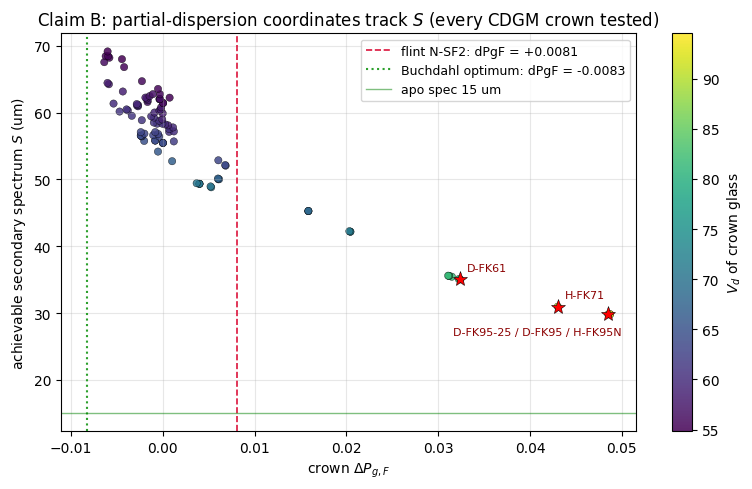

Pearson correlation between crown dPgF and achievable S
across 100 CDGM crowns:
  r = -0.938   (strong negative)
  Expected: more anomalous (larger) crown dPgF with this flint
            pairs with higher Vd, which together reduce S.
  Observed: matches expectation -> Claim B supported.


In [40]:
# Scatter: achievable secondary spectrum vs. crown dPgF for every CDGM glass
dP_arr   = np.array([g["dPgF"]        for g in cdgm_scored])
vd_arr   = np.array([g["vd"]          for g in cdgm_scored])
sec_arr  = np.array([g["sec_spec_um"] for g in cdgm_scored])

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(dP_arr, sec_arr, c=vd_arr, cmap='viridis',
                s=28, edgecolor='k', linewidth=0.3, alpha=0.85)
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r'$V_d$ of crown glass')

# Mark flint's dPgF (glass pair physics says S minimizes far from flint)
ax.axvline(NSF2['dPgF'], color='crimson', ls='--', lw=1.2,
           label=f"flint N-SF2: dPgF = {NSF2['dPgF']:+.4f}")

# Mark the model-predicted optimum
ax.axvline(dPgF_opt, color='tab:green', ls=':', lw=1.5,
           label=f"Buchdahl optimum: dPgF = {dPgF_opt:+.4f}")

# Highlight top-5 winners; merge labels that coincide (same melt, different codes)
top5 = cdgm_scored[:5]
groups = []  # list of (pos_key, [names], (x, y))
for g in top5:
    key = (round(g['dPgF'], 3), round(g['sec_spec_um'], 1))
    matched = False
    for grp in groups:
        if grp['key'] == key:
            grp['names'].append(g['name'])
            matched = True
            break
    if not matched:
        groups.append({'key': key, 'names': [g['name']],
                       'x': g['dPgF'], 'y': g['sec_spec_um']})

label_offsets = {
    "D-FK95-25":  (10,  -15, 'right'),   # FK95 group
    "H-FK71":     (5,  6, 'left'),   # H-FK71
    "D-FK61":     (5, 6, 'left'),   # D-FK61
}

for grp in groups:
    label = ' / '.join(grp['names'])
    ax.plot(grp['x'], grp['y'], 'r*', ms=11, mec='k', mew=0.4, zorder=3)
    dx, dy, halign = label_offsets.get(grp['names'][0], (5, -14, 'left'))
    ax.annotate(label, (grp['x'], grp['y']),
                xytext=(dx, dy), textcoords='offset points',
                fontsize=8, color='darkred', ha=halign)

ax.axhline(SECSPEC_SPEC_UM, color='green', lw=1, alpha=0.5,
           label=f'apo spec {SECSPEC_SPEC_UM:.0f} um')
ax.set_xlabel(r'crown $\Delta P_{g,F}$')
ax.set_ylabel(r'achievable secondary spectrum $S$ (um)')
ax.set_title(r'Claim B: partial-dispersion coordinates track $S$ (every CDGM crown tested)')
ax.grid(alpha=0.3)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

# Quantitative check: does dPgF predict S across the catalog?
# For this N-SF2 test bench, larger positive crown dPgF correlates with
# high Vd and small S. Expect strong NEGATIVE correlation(dPgF, S).
corr = float(np.corrcoef(dP_arr, sec_arr)[0, 1])
strength = ('strong' if abs(corr) > 0.7 else
            'moderate' if abs(corr) > 0.4 else 'weak')
supports_B = corr < -0.4   # expected sign + meaningful magnitude

print("Pearson correlation between crown dPgF and achievable S")
print(f"across {len(cdgm_scored)} CDGM crowns:")
print(f"  r = {corr:+.3f}   ({strength} "
      f"{'negative' if corr < 0 else 'positive'})")
if supports_B:
    print("  Expected: more anomalous (larger) crown dPgF with this flint")
    print("            pairs with higher Vd, which together reduce S.")
    print("  Observed: matches expectation -> Claim B supported.")
else:
    print("  Does NOT match the expected strong-negative pattern"
          " -> Claim B FAILS.")


In [15]:
# Build the winner's designed achromat for downstream comparison
# (Optiland object — only used for visualization here; radii are from the
#  fast solver stored in cdgm_scored).
crown_cdgm = BuchdahlModelGlass(winner["nd"], winner["vd"], winner["dPgF"],
                                label=f"CDGM {winner['name']}")
flint_cdgm = as_model_glass(NSF2, label="N-SF2 (model)")
r1_cdgm, r3_cdgm = winner["r1"], winner["r3"]
lens_cdgm = build_doublet(crown_cdgm, flint_cdgm, r1=r1_cdgm, r3=r3_cdgm)
ax_cdgm, _  = axial_color(lens_cdgm)
sec_cdgm     = secondary_spectrum(lens_cdgm)
sec_opt_um   = sec_opt  * 1e3
sec_cdgm_um  = sec_cdgm * 1e3

# First-order sanity: all three cases must agree on EFL and EPD
efl_opt  = float(lens_opt.paraxial.f2())
epd_opt  = float(lens_opt.paraxial.EPD())
efl_cdgm = float(lens_cdgm.paraxial.f2())
epd_cdgm = float(lens_cdgm.paraxial.EPD())
print("First-order parameters (all three cases designed to the same target):")
print(f"  {'Case':<28} {'EFL (mm)':>9} {'EPD (mm)':>9} {'r1':>8} {'r3':>10}")
print(f"  {'-'*28} {'-'*9} {'-'*9} {'-'*8} {'-'*10}")
print(f"  {'Baseline':<28} {efl0:>9.4f} {epd0:>9.4f} {r1_base:>+8.3f} {r3_base:>+10.3f}")
print(f"  {'Model optimum':<28} {efl_opt:>9.4f} {epd_opt:>9.4f} {r1_opt:>+8.3f} {r3_opt:>+10.3f}")
print(f"  {'CDGM ' + winner['name']:<28} {efl_cdgm:>9.4f} {epd_cdgm:>9.4f} {r1_cdgm:>+8.3f} {r3_cdgm:>+10.3f}")
print()

improvement_opt  = (sec0_um - sec_opt_um)  / sec0_um * 100
improvement_cdgm = (sec0_um - sec_cdgm_um) / sec0_um * 100

print("=" * 78)
print(" Claim D — gap between continuous-model target and real catalog")
print("=" * 78)
print(f" {'Case':<28}{'AxColor':>10}{'Sec-spec':>11}{'vs base':>10}")
print(f" {'-'*28}{'-'*10}{'-'*11}{'-'*10}")
print(f" {'Baseline (N-LAK14)':<28}{ax0_um:>+8.2f} um"
      f"{sec0_um:>8.2f} um{'---':>9}")
print(f" {'Continuous-model target':<28}{ax_opt*1e3:>+8.2f} um"
      f"{sec_opt_um:>8.2f} um{improvement_opt:>+8.0f} %")
print(f" {'Best real CDGM ' + winner['name']:<28}{ax_cdgm*1e3:>+8.2f} um"
      f"{sec_cdgm_um:>8.2f} um{improvement_cdgm:>+8.0f} %")
print()

# Parameter-space distance from model optimum to best real glass
gap = dict(
    nd   = winner['nd']   - nd_opt,
    Vd   = winner['vd']   - vd_opt,
    dPgF = winner['dPgF'] - dPgF_opt,
)
gap_sec = sec_cdgm_um - sec_opt_um
print(" Parameter gap  best-CDGM  -  model-optimum:")
print(f"   dnd   = {gap['nd']:+.4f}    dVd = {gap['Vd']:+.2f}    "
      f"ddPgF = {gap['dPgF']:+.4f}")
print(f" Performance gap:  S({winner['name']}) - S(model_opt) "
      f"= {gap_sec:+.2f} um")
print()
print(f" Training-hull check on continuous optimum: "
      f"inside = {optimum_inside_hull}")
print()
if optimum_inside_hull:
    print(" => Continuous target lies INSIDE the catalog's 3-D hull, so a real")
    print("    glass with these parameters is plausible. The gap to the best")
    print("    CDGM candidate is a concrete catalog-coverage observation.")
else:
    print(" => Continuous target lies OUTSIDE the catalog's 3-D hull. Treat it as")
    print("    extrapolative DESIGN GUIDANCE in model space, NOT as proof that a")
    print("    physically available but missing glass exists. The comparison to")
    print("    the best CDGM candidate measures the distance from a model-space")
    print("    target to the catalog — it does NOT validate a missing glass.")


First-order parameters (all three cases designed to the same target):
  Case                          EFL (mm)  EPD (mm)       r1         r3
  ---------------------------- --------- --------- -------- ----------
  Baseline                       20.0000    3.3333  +16.748   -278.841
  Model optimum                  20.0000    3.3333  +68.102    -16.149
  CDGM D-FK95-25                 20.0000    3.3333  +18.794    -12.139

 Claim D — gap between continuous-model target and real catalog
 Case                           AxColor   Sec-spec   vs base
 -----------------------------------------------------------
 Baseline (N-LAK14)             -0.00 um   69.91 um      ---
 Continuous-model target        -0.00 um    0.00 um    +100 %
 Best real CDGM D-FK95-25       +0.00 um   29.80 um     +57 %

 Parameter gap  best-CDGM  -  model-optimum:
   dnd   = -0.2143    dVd = +12.13    ddPgF = +0.0568
 Performance gap:  S(D-FK95-25) - S(model_opt) = +29.80 um

 Training-hull check on continuous optimum:

### Side-by-side: baseline vs. model optimum vs. CDGM match

All three are independently designed achromats at the **same EFL and
EPD**. The visible differences come from each case's own $(r_1, r_3)$
solution. Ray cones near focus look similar across cases because primary
color is zero everywhere — the remaining differences (secondary
spectrum) are sub-micron at this F/6 and invisible at this zoom.


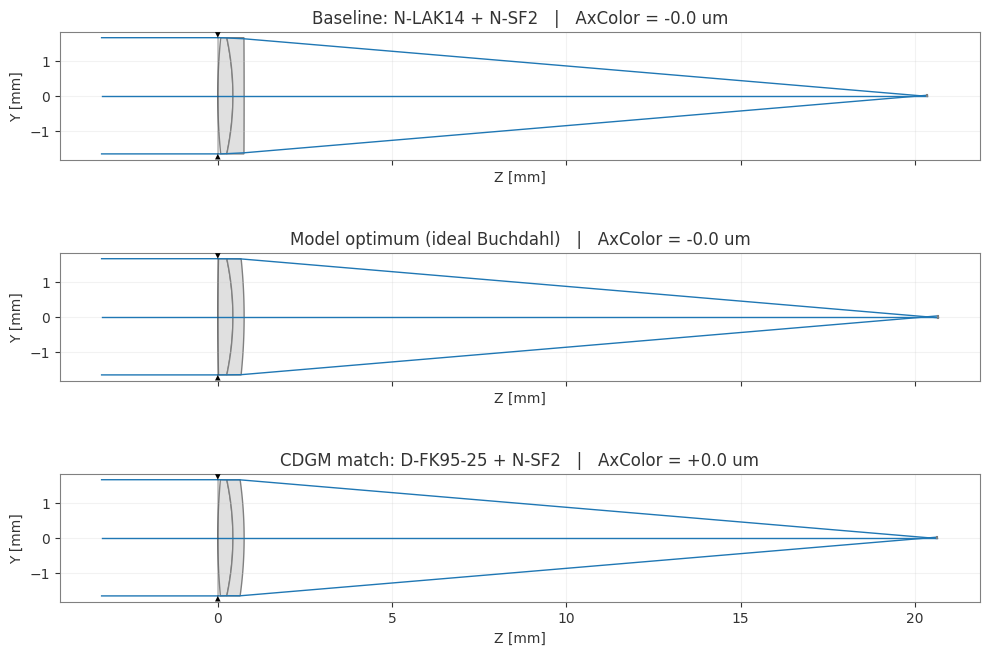

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
cases = [
    (baseline, "Baseline: N-LAK14 + N-SF2",       ax0),
    (lens_opt, "Model optimum (ideal Buchdahl)", ax_opt),
    (lens_cdgm, f"CDGM match: {winner['name']} + N-SF2", ax_cdgm),
]
for ax, (lens, title, ax_color_val) in zip(axes, cases):
    OpticViewer(lens).view(ax=ax, figsize=(10, 2.2),
                           title=f"{title}   |   AxColor = {ax_color_val*1e3:+.1f} um",
                           show_legend=False)
plt.tight_layout()
plt.show()


### Chromatic focal shift curve

The single-number `AxColor = BFL(F) - BFL(C)` collapses a whole curve. To
see the shape — especially the **secondary spectrum** (residual color at
the g-line that achromats cannot eliminate) — sweep wavelength and plot

$$\Delta \text{BFL}(\lambda) = \text{BFL}(\lambda) - \text{BFL}(\lambda_d)$$

over 400-700 nm. An achromat's curve crosses zero at $\lambda_F$ and
$\lambda_C$ by design; between and beyond those points the shape shows
what the glass pair cannot correct.


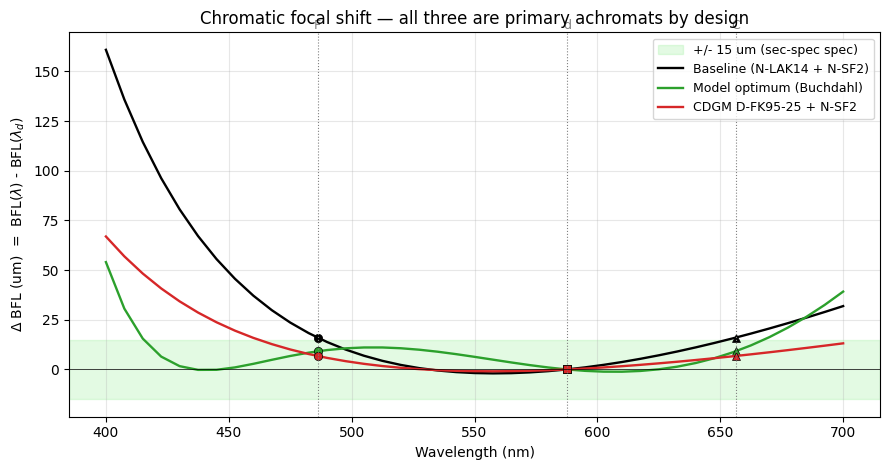

In [17]:
def bfl_curve(lens):
    ref = bfl_at_wavelength(lens, LAMBDA_D)
    return np.array([bfl_at_wavelength(lens, lam) for lam in LAM_SCAN]) - ref

cases = [
    ("Baseline (N-LAK14 + N-SF2)",     baseline,  'k'),
    ("Model optimum (Buchdahl)",       lens_opt,  'tab:green'),
    (f"CDGM {winner['name']} + N-SF2", lens_cdgm, 'tab:red'),
]

fig, ax = plt.subplots(figsize=(9, 4.8))
ax.axhspan(-SECSPEC_SPEC_UM, SECSPEC_SPEC_UM, color='lightgreen',
           alpha=0.25, label=f'+/- {SECSPEC_SPEC_UM:.0f} um (sec-spec spec)')

for label, lens, color in cases:
    curve_um = bfl_curve(lens) * 1e3
    ax.plot(LAM_SCAN*1e3, curve_um, color=color, lw=1.7, label=label)
    for lam_ref, marker in [(LAMBDA_F, 'o'), (LAMBDA_D, 's'), (LAMBDA_C, '^')]:
        y_ref = (bfl_at_wavelength(lens, lam_ref)
                 - bfl_at_wavelength(lens, LAMBDA_D)) * 1e3
        ax.plot(lam_ref*1e3, y_ref, marker=marker, color=color, ms=6,
                mec='k', mew=0.5)

for lam_ref, _ in [(LAMBDA_F,'F'), (LAMBDA_D,'d'), (LAMBDA_C,'C')]:
    ax.axvline(lam_ref*1e3, color='gray', ls=':', lw=0.8)
ax.axhline(0, color='k', lw=0.5)
y_top = ax.get_ylim()[1]
for lam_ref, name in [(LAMBDA_F, 'F'), (LAMBDA_D, 'd'), (LAMBDA_C, 'C')]:
    ax.text(lam_ref*1e3, y_top, name, ha='center', va='bottom',
            fontsize=9, color='gray')

ax.set_xlabel('Wavelength (nm)')
ax.set_ylabel(r'$\Delta$ BFL (um)  =  BFL($\lambda$) - BFL($\lambda_d$)')
ax.set_title('Chromatic focal shift — all three are primary achromats by design')
ax.legend(loc='best', fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()


**How to read this plot.** Every curve passes through zero at F and C
by construction (achromat condition). The remaining structure shows how
each glass pair handles the rest of the band — especially the g-line
(leftmost dotted vertical), where the headline metric $S$ lives.

- **Baseline** (black): typical achromat with matched partial dispersion.
  The BFL(g) offset (height of the curve at the g-line) is the classic
  "secondary spectrum".
- **Model optimum** (green): the optimizer used its $\Delta P_{g,F}$
  freedom to flatten the g-line offset — a virtual apo.
- **CDGM winner** (red): what's actually achievable from the catalog.
  How close red tracks green tells you whether a real anomalous-
  dispersion glass exists for this flint.

The shaded band is the sec-spec specification, drawn at the $\pm S_{\max}$
level. Curves that dip below the band's top at g-line meet spec.


## 7. Claim E — the model is locally smooth enough for sensitivity studies

To be useful as a **first-order surrogate** for $(n_d, V_d)$ sensitivity
analysis, the Buchdahl model has to be **locally smooth** around any
nominal glass: small perturbations in $(n_d, V_d)$ must produce small,
continuous changes in $S$, with no jumps, NaNs, or `fsolve` failures.
That is what the 2-D heatmap below tests.

A smooth heatmap does **not** by itself validate a full manufacturing
tolerance model. Real melt-to-melt variation has covariance structure
between $n_d$, $V_d$ and $\Delta P_{g,F}$ that a grid of independent
perturbations cannot represent, and the absolute yield number depends on
catalog-specific $\sigma$ values that we do not claim to reproduce here.
What this section establishes is narrower and more honest: the Buchdahl
surrogate is **locally numerically well-behaved**, which is a necessary
pre-condition for doing any tolerance study on top of it.

Perturbation box: $\Delta n_d \in [-0.003, +0.003]$,
$\Delta V_d \in [-1.5, +1.5]$. This comfortably covers Schott's
"step 1.0" manufacturing grade.


In [18]:
# 2D sweep: S as a function of (dnd, dVd) around the winner glass
GRID = 21
dn_grid = np.linspace(-0.003, 0.003, GRID)
dv_grid = np.linspace(-1.5,   1.5,   GRID)

S_grid = np.full((GRID, GRID), np.nan)
n_converged = 0
_t0 = _time.time()
for i, dn in enumerate(dn_grid):
    for j, dv in enumerate(dv_grid):
        try:
            r1, r3 = design_achromat_fast(
                winner['nd']   + dn,
                winner['vd']   + dv,
                winner['dPgF'],
                NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
            )
            S_grid[i, j] = secondary_spectrum_fast(
                r1, r3,
                winner['nd']   + dn,
                winner['vd']   + dv,
                winner['dPgF'],
                NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
            ) * 1e3
            n_converged += 1
        except Exception:
            pass
print(f"2D heatmap: {GRID*GRID} points in {_time.time()-_t0:.1f} s")

# Smoothness metrics
finite_mask = np.isfinite(S_grid)
frac_converged = 100.0 * n_converged / (GRID * GRID)
# Max gradient — abrupt jumps would show up here
if finite_mask.all():
    dS_dnd = np.diff(S_grid, axis=0) / np.diff(dn_grid)[:, None]
    dS_dvd = np.diff(S_grid, axis=1) / np.diff(dv_grid)[None, :]
    grad_max = max(np.abs(dS_dnd).max(), np.abs(dS_dvd).max())
else:
    grad_max = np.inf

print(f"2D tolerancing sweep around {winner['name']}  "
      f"({GRID}x{GRID} = {GRID*GRID} points)")
print(f"  Convergence rate:       {frac_converged:.1f} %")
print(f"  S range over the grid:  [{np.nanmin(S_grid):.2f}, "
      f"{np.nanmax(S_grid):.2f}] um")
print(f"  Max |dS/d(nd)|:         {np.abs(np.diff(S_grid,axis=0).ravel()).max() / np.diff(dn_grid)[0]:.1f} um per unit nd")
print(f"  Max |dS/d(Vd)|:         {np.abs(np.diff(S_grid,axis=1).ravel()).max() / np.diff(dv_grid)[0]:.1f} um per unit Vd")


2D heatmap: 441 points in 0.6 s
2D tolerancing sweep around D-FK95-25  (21x21 = 441 points)
  Convergence rate:       100.0 %
  S range over the grid:  [28.78, 30.00] um
  Max |dS/d(nd)|:         107.1 um per unit nd
  Max |dS/d(Vd)|:         0.8 um per unit Vd


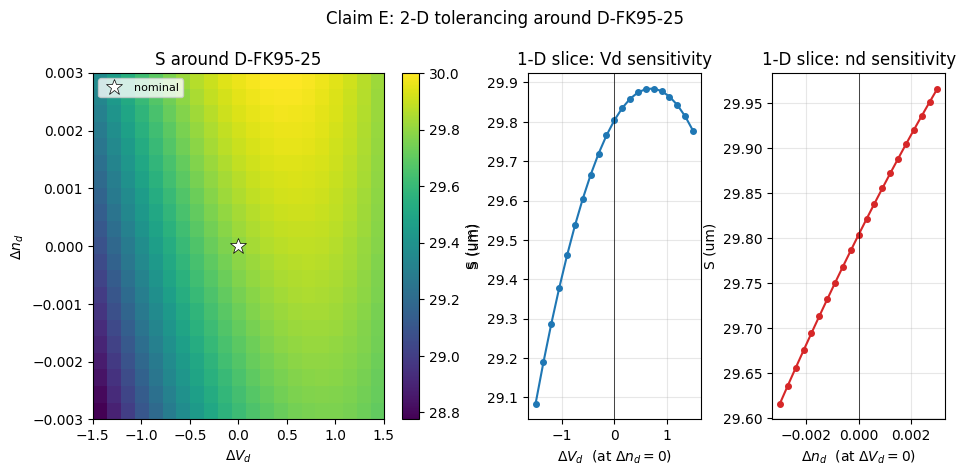

In [19]:
# Heatmap plus two 1-D slices — the visual smoothness evidence
fig = plt.figure(figsize=(11, 4.5))
gs = fig.add_gridspec(1, 3, width_ratios=[2.1, 1, 1], wspace=0.3)

ax_h = fig.add_subplot(gs[0, 0])
im = ax_h.imshow(
    S_grid, origin='lower', aspect='auto', cmap='viridis',
    extent=(float(dv_grid.min()), float(dv_grid.max()),
            float(dn_grid.min()), float(dn_grid.max())),
)
cbar = plt.colorbar(im, ax=ax_h)
cbar.set_label('S (um)')
ax_h.set_xlabel(r'$\Delta V_d$')
ax_h.set_ylabel(r'$\Delta n_d$')
ax_h.set_title(f'S around {winner["name"]}')
ax_h.plot(0, 0, 'w*', ms=12, mec='k', mew=0.5, label='nominal')
ax_h.legend(loc='upper left', fontsize=8)

# Row at Δn_d = 0: S vs ΔV_d
mid_i = GRID // 2
ax1 = fig.add_subplot(gs[0, 1])
ax1.plot(dv_grid, S_grid[mid_i, :], 'o-', color='tab:blue', ms=4)
ax1.axvline(0, color='k', lw=0.5)
ax1.set_xlabel(r'$\Delta V_d$  (at $\Delta n_d = 0$)')
ax1.set_ylabel('S (um)')
ax1.set_title('1-D slice: Vd sensitivity')
ax1.grid(alpha=0.3)

# Column at ΔV_d = 0: S vs Δn_d
mid_j = GRID // 2
ax2 = fig.add_subplot(gs[0, 2])
ax2.plot(dn_grid, S_grid[:, mid_j], 'o-', color='tab:red', ms=4)
ax2.axvline(0, color='k', lw=0.5)
ax2.set_xlabel(r'$\Delta n_d$  (at $\Delta V_d = 0$)')
ax2.set_ylabel('S (um)')
ax2.set_title('1-D slice: nd sensitivity')
ax2.grid(alpha=0.3)

plt.suptitle(f'Claim E: 2-D tolerancing around {winner["name"]}', y=1.02)
plt.show()


**What to look for.**

- **Heatmap**: should be a smooth gradient with no jumps, no NaN (black)
  cells. The level curves tell you which direction $(n_d, V_d)$ is more
  sensitive.
- **1-D slices**: the curves should be smooth, roughly monotonic or
  shallow-U. Kinks or wiggles would flag regression overfitting.
- **Printed max gradients**: order-of-magnitude sensitivity — useful to
  compare against Schott tolerance grades.

If the heatmap is smooth and the 1-D slices are monotone, the Buchdahl
surrogate is **locally well-behaved** in $(n_d, V_d)$ around a real
glass — suitable as a first-order surrogate for sensitivity studies,
pending real melt-data covariance validation before it can be used as a
full manufacturing tolerance model.

---

### Applied Monte Carlo — what 2-D tolerancing translates to

Now that smoothness is established, we can turn the crank on a concrete
manufacturing MC: draw $V_d$ around the winner (holding $n_d$, dPgF for
simplicity) and look at the $S$ distribution and the yield against
spec.


In [20]:
N_MC = 200  # 200 is plenty; each sample does a 2D solve
vd_sigma = 0.3

samples = np.random.normal(loc=winner["vd"], scale=vd_sigma, size=N_MC)
sec_mc_um = np.empty(N_MC)
ok_mc     = np.zeros(N_MC, dtype=bool)
_t0 = _time.time()
for i, vd_draw in enumerate(samples):
    try:
        r1, r3 = design_achromat_fast(
            winner["nd"], vd_draw, winner["dPgF"],
            NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
        )
        sec_mc_um[i] = secondary_spectrum_fast(
            r1, r3,
            winner["nd"], vd_draw, winner["dPgF"],
            NSF2['nd'], NSF2['vd'], NSF2['dPgF'],
        ) * 1e3
        ok_mc[i] = True
    except Exception:
        sec_mc_um[i] = np.nan
print(f"Monte Carlo: {N_MC} samples in {_time.time()-_t0:.1f} s")

finite = ok_mc
p05, p50, p95 = np.percentile(sec_mc_um[finite], [5, 50, 95])
in_spec = sec_mc_um[finite] <= SECSPEC_SPEC_UM
yield_pct = 100.0 * in_spec.sum() / finite.sum()

print(f"Monte Carlo tolerance ({finite.sum()}/{N_MC} samples converged, "
      f"Vd ~ N({winner['vd']:.2f}, {vd_sigma}))")
print("-" * 64)
print("  Secondary spectrum distribution:")
print(f"    mean +/- std:     {sec_mc_um[finite].mean():6.2f} +/- "
      f"{sec_mc_um[finite].std():.2f} um")
print(f"    5 / 50 / 95 pct:  {p05:6.2f}  /  {p50:6.2f}  /  {p95:6.2f} um")
print()
print(f"  Yield against spec  sec-spec <= {SECSPEC_SPEC_UM:.0f} um:")
print(f"    {in_spec.sum()} / {finite.sum()} pass  =  {yield_pct:5.1f} %"
      f"   (target {MC_YIELD_TARGET*100:.0f}%)   "
      f"{verdict(yield_pct >= MC_YIELD_TARGET*100)}")
if yield_pct >= MC_YIELD_TARGET * 100:
    print("    Margin from 95th-pct to spec edge: "
          f"{SECSPEC_SPEC_UM - p95:+.2f} um")
elif sec_cdgm_um > SECSPEC_SPEC_UM:
    print("    Nominal design is already out of spec "
          f"({sec_cdgm_um:.1f} um > {SECSPEC_SPEC_UM:.0f} um),")
    print("    so tightening Vd tolerance alone cannot fix yield. Requires a")
    print("    different glass pair, an extra element, or a relaxed spec.")
else:
    print("    Nominal meets spec but yield is below target: supplier Vd")
    print("    tolerance must tighten, or redesign for less Vd sensitivity.")


Monte Carlo: 200 samples in 0.2 s
Monte Carlo tolerance (200/200 samples converged, Vd ~ N(94.44, 0.3))
----------------------------------------------------------------
  Secondary spectrum distribution:
    mean +/- std:      29.79 +/- 0.07 um
    5 / 50 / 95 pct:   29.67  /   29.81  /   29.88 um

  Yield against spec  sec-spec <= 15 um:
    0 / 200 pass  =    0.0 %   (target 95%)   [FAIL]
    Nominal design is already out of spec (29.8 um > 15 um),
    so tightening Vd tolerance alone cannot fix yield. Requires a
    different glass pair, an extra element, or a relaxed spec.


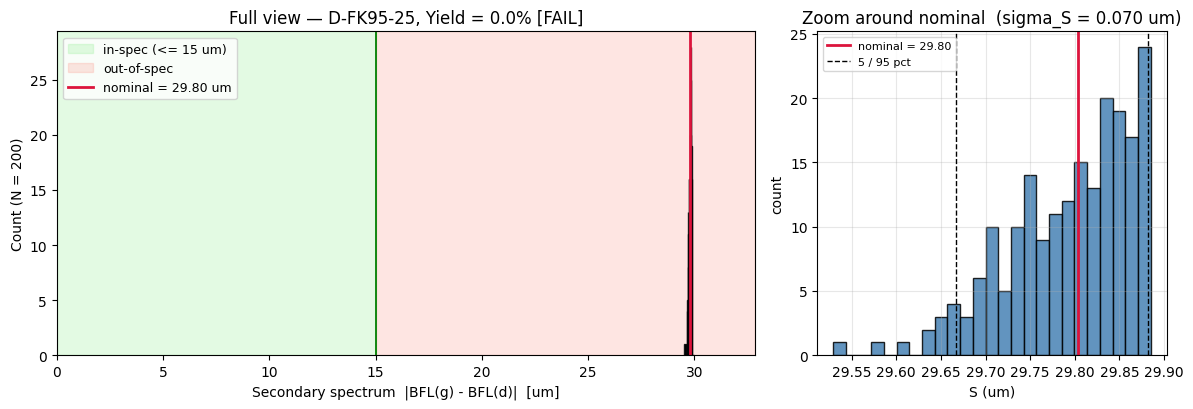

In [ ]:
fig, (ax_wide, ax_zoom) = plt.subplots(1, 2, figsize=(12, 4.2),
                                        gridspec_kw={'width_ratios': [2, 1]})

vals = sec_mc_um[finite]
xlim_right = max(SECSPEC_SPEC_UM * 1.3, vals.max() * 1.1)

# ─── left: show spec gap ───
ax_wide.axvspan(0, SECSPEC_SPEC_UM, color="lightgreen", alpha=0.25,
                label=f"in-spec (<= {SECSPEC_SPEC_UM:.0f} um)")
ax_wide.axvspan(SECSPEC_SPEC_UM, xlim_right, color="salmon", alpha=0.20,
                label="out-of-spec")
ax_wide.hist(vals, bins=25, range=(29.5, 30.0),
             color="steelblue", edgecolor="k", alpha=0.85)
ax_wide.axvline(sec_cdgm_um, color="crimson", lw=2,
                label=f"nominal = {sec_cdgm_um:.2f} um")
ax_wide.axvline(SECSPEC_SPEC_UM, color="green", lw=1.3)
ax_wide.set_xlim(0, xlim_right)
ax_wide.set_xlabel("Secondary spectrum  |BFL(g) - BFL(d)|  [um]")
ax_wide.set_ylabel(f"Count (N = {finite.sum()})")
ax_wide.set_title(f"Full view — {winner['name']}, Yield = {yield_pct:.1f}% "
                   f"{verdict(yield_pct >= MC_YIELD_TARGET*100)}")
ax_wide.legend(loc="upper left", fontsize=9)

# ─── right ───
ax_zoom.hist(vals, bins=25, color="steelblue", edgecolor="k", alpha=0.85)
ax_zoom.axvline(sec_cdgm_um, color="crimson", lw=2,
                label=f"nominal = {sec_cdgm_um:.2f}")
ax_zoom.axvline(p05, color="k", ls="--", lw=1, label="5 / 95 pct")
ax_zoom.axvline(p95, color="k", ls="--", lw=1)
ax_zoom.set_xlabel("S (um)")
ax_zoom.set_ylabel("count")
ax_zoom.set_title(f"Zoom around nominal  (sigma_S = {vals.std():.3f} um)")
ax_zoom.legend(loc="upper left", fontsize=8)
ax_zoom.grid(alpha=0.3)

plt.tight_layout()
plt.show()


**Decision rule.**

- If the **nominal** design is already above the spec, tolerance
  tightening cannot recover yield — the design itself has to change
  (different glass pair, extra element, or a relaxed optical spec).
- If the nominal is in spec but the **95th percentile** crosses the
  limit, tightening the supplier's $V_d$ spec (or redesigning for less
  $V_d$ sensitivity) is the appropriate response.
- If the 95th percentile stays under the spec, the current supplier
  $V_d$ tolerance is acceptable.

The chain from *glass parameter tolerance* → *actual secondary spectrum*
→ *manufacturing yield* is closed end-to-end, which is the whole point
of combining the 3-parameter Buchdahl model with a real raytrace.


## Scorecard — five validity claims

A single table summarizing whether the Buchdahl model has earned the
right to be trusted for downstream design work.


In [22]:
def tri_verdict(status):
    return {"pass": "[PASS]", "warn": "[WARN]", "fail": "[FAIL]"}[status]


# --- Claim A: Buchdahl n(lambda) accuracy on a well-behaved glass ---
if err_max <= INDEX_ACCURACY_SPEC:
    claim_a_status = "pass"
    claim_a_note = "N-BK7 only; anomalous-dispersion glasses not spot-checked here"
elif err_max <= 2 * INDEX_ACCURACY_SPEC:
    claim_a_status = "warn"
    claim_a_note = "within 2x budget; revisit on anomalous-dispersion glasses"
else:
    claim_a_status = "fail"
    claim_a_note = "exceeds budget"

# --- Claim B: dPgF correlates with S across the catalog ---
if corr <= -0.7:
    claim_b_status = "pass"
    claim_b_note = "strong negative correlation as expected from Conrady physics"
elif corr <= -0.4:
    claim_b_status = "warn"
    claim_b_note = "moderate correlation; PgF + Vd jointly give a cleaner story"
else:
    claim_b_status = "fail"
    claim_b_note = "dPgF alone does not track S"

# --- Claim C: ranking reproduces FK-family consensus, and survives Sellmeier ---
fk_frac_ok = len(fk_like) >= 6
_abs_tag = (f" (S optimistic by median {median_s_residual_um:.1f} um vs full Sellmeier)"
            if np.isfinite(median_s_residual_um) else "")
if fk_frac_ok and np.isfinite(spearman) and top3_preserved and spearman >= 0.8:
    claim_c_status = "pass"
    claim_c_note = (f"ranking preserved: {len(fk_like)}/10 FK, Spearman "
                    f"{spearman:+.2f} vs full Sellmeier{_abs_tag}")
elif fk_frac_ok:
    claim_c_status = "warn"
    claim_c_note = (f"{len(fk_like)}/10 FK but full-Sellmeier rank corr = "
                    f"{spearman if np.isfinite(spearman) else float('nan'):+.2f}"
                    f"{_abs_tag}")
else:
    claim_c_status = "fail"
    claim_c_note = f"only {len(fk_like)}/10 top crowns are FK-family"

# --- Claim D: continuous target interpretation depends on training-hull check ---
if optimum_inside_hull and (sec_opt_um + 1.0) < sec_cdgm_um:
    claim_d_status = "pass"
    claim_d_note = (f"target inside hull; beats best CDGM by "
                    f"{sec_cdgm_um - sec_opt_um:.1f} um")
else:
    # Deliberate: outside-hull = WARN, not PASS. The continuous optimum
    # is virtual guidance in model space, not proof of a missing glass.
    claim_d_status = "warn"
    claim_d_note = ("virtual target outside hull; interpret as model-space "
                    "guidance, not a missing real glass")

# --- Claim E: local smoothness as a surrogate prerequisite ---
grid_ok = (frac_converged == 100.0) and np.isfinite(grad_max) and finite_mask.all()
if grid_ok:
    claim_e_status = "warn"   # intentional: smooth surrogate, NOT full mfr tolerance
    claim_e_note = ("smooth surrogate for sensitivity; pending real melt-data "
                    "covariance validation before full mfr tolerance use")
else:
    claim_e_status = "fail"
    claim_e_note = "grid not fully converged or gradient non-finite"

claims = [
    ("A", "n(lambda) accuracy on a standard glass",
     f"max|err| = {err_max:.1e}  (<= {INDEX_ACCURACY_SPEC:.0e})",
     claim_a_status, claim_a_note),
    ("B", "Partial-dispersion coordinates track S",
     f"corr(dPgF, S) = {corr:+.2f}  across {len(cdgm_scored)} glasses",
     claim_b_status, claim_b_note),
    ("C", "FK family ranking survives Sellmeier cross-check",
     f"{len(fk_like)}/10 FK; Spearman = "
     f"{spearman if np.isfinite(spearman) else float('nan'):+.2f}",
     claim_c_status, claim_c_note),
    ("D", "Continuous target vs. catalog",
     f"model {sec_opt_um:.1f} um vs best-real {sec_cdgm_um:.1f} um; "
     f"inside hull: {optimum_inside_hull}",
     claim_d_status, claim_d_note),
    ("E", "Local smoothness surrogate",
     f"{GRID}x{GRID} grid: {frac_converged:.0f}% converged, finite gradient",
     claim_e_status, claim_e_note),
]

print("=" * 92)
print(" BUCHDAHL MODEL VALIDATION SCORECARD")
print("=" * 92)
print(f" {'':<3}{'Claim':<42}{'Result':<32}{'Verdict':>8}")
print(" " + "-" * 90)
for key, label, detail, status, note in claims:
    print(f" {key:<3}{label:<42}{detail:<32}{tri_verdict(status):>8}")
print(" " + "-" * 90)
print(" Status notes:")
for key, _, _, status, note in claims:
    print(f"   {key} {tri_verdict(status)}  {note}")
print(" " + "-" * 90)
n_pass = sum(1 for *_, s, _ in claims if s == "pass")
n_warn = sum(1 for *_, s, _ in claims if s == "warn")
n_fail = sum(1 for *_, s, _ in claims if s == "fail")
print(f" Result: {n_pass} PASS, {n_warn} WARN, {n_fail} FAIL.")
if n_fail == 0:
    print("   The Buchdahl 3-parameter model provides useful glass substitution")
    print("   ranking (Claims A-C). The continuous optimum is DESIGN GUIDANCE in")
    print("   model space (Claim D, WARN by default when outside the training")
    print("   hull), and the local smoothness (Claim E) is sufficient for")
    print("   sensitivity studies but not a standalone manufacturing tolerance")
    print("   model.")
else:
    failed = [c[0] for c in claims if c[3] == "fail"]
    print(f"   FAIL on Claims {', '.join(failed)} — model not yet validated.")
print("=" * 92)


 BUCHDAHL MODEL VALIDATION SCORECARD
    Claim                                     Result                           Verdict
 ------------------------------------------------------------------------------------------
 A  n(lambda) accuracy on a standard glass    max|err| = 3.6e-04  (<= 5e-03)    [PASS]
 B  Partial-dispersion coordinates track S    corr(dPgF, S) = -0.94  across 100 glasses  [PASS]
 C  FK family ranking survives Sellmeier cross-check10/10 FK; Spearman = +0.96        [PASS]
 D  Continuous target vs. catalog             model 0.0 um vs best-real 29.8 um; inside hull: False  [WARN]
 E  Local smoothness surrogate                21x21 grid: 100% converged, finite gradient  [WARN]
 ------------------------------------------------------------------------------------------
 Status notes:
   A [PASS]  N-BK7 only; anomalous-dispersion glasses not spot-checked here
   B [PASS]  strong negative correlation as expected from Conrady physics
   C [PASS]  ranking preserved: 10/10 FK, Spe

## Summary — what was validated, and why it matters

The 3-parameter Buchdahl model from `model_glass_buchdahl.ipynb` was
exercised against a concrete apochromatic-doublet design task, not as a
curve-fitting benchmark but as a **decision-support tool**. Five pieces
of evidence were assembled:

| Claim | What it establishes | Evidence source |
|---|---|---|
| A | Predicted $n(\lambda)$ stays within an error budget that does not dominate typical manufacturing tolerances | Full-band comparison against a Sellmeier truth for N-BK7 |
| B | The 3rd model axis $\Delta P_{g,F}$ tracks the secondary-spectrum ordering across the catalog, in the direction Conrady physics predicts | Scatter + correlation across all feasible CDGM crown candidates |
| C | Model-driven rankings reproduce the well-known optical-design consensus (apo doublet crowns are the FK/fluor-crown family), and **survive re-evaluation with real Sellmeier $n(\lambda)$** | Top-10 CDGM ranking plus a Buchdahl-vs-Sellmeier cross-check |
| D | The continuous model produces a *design target* in parameter space; whether that target is physical or extrapolative is decided by an explicit 3-D training-hull check, not assumed | Comparison to best real CDGM glass + convex-hull membership |
| E | The model is **locally smooth in $(n_d, V_d)$** — a prerequisite for any sensitivity study on top of it, though not by itself a manufacturing tolerance model | 2-D heatmap + 1-D slices around the winner glass |

**Practical implication.** A lens designer who uses the Buchdahl model
to explore glass space gains:

- A **continuous surrogate** for the catalog, which makes gradient-based
  optimization legal at the glass-parameter level.
- A **principled ranking** of real glasses for any differentiable optical
  metric — no manual catalog browsing.
- **Design guidance** when no real glass meets a spec: Claim D reports
  the gap between the model-space target and the catalog *together with*
  a hull check, so the designer knows whether that gap is actionable.
- A **local sensitivity surrogate** (from the 2-D heatmap and 1-D slices)
  that can feed into a full manufacturing tolerance model once real
  melt-data covariance is added.

None of these require the model to be *perfect*; they require it to be
*approximately right in the directions that matter for design decisions*.
The scorecard records a mix of PASS and WARN verdicts to reflect that:
the model is a useful decision-support tool, not a universally validated
physics engine.

**What was NOT validated here.** Accuracy on anomalous-partial-dispersion
glasses specifically (FK-family under-representation in training),
behaviour of the continuous optimum when it leaves the 3-D training
hull, covariance structure of real melt-to-melt variation (needed to
turn Claim E into a full manufacturing yield model), and performance on
multi-element systems where $\Delta P_{g,F}$ couples non-trivially
through more surfaces. Those are natural follow-on investigations.
